# Análisis Topológico de Datos: Ácido Fólico → Resultados Materno-Infantiles
**Objetivo:** Usar TDA (Mapper + Homología Persistente) para descubrir
subpoblaciones de mujeres embarazadas con distintos patrones de consumo
de ácido fólico (AF) y su relación con resultados de salud del hijo y la madre.
**Estructura:**
1. Carga de datos y definición de espacios de features
2. Verificación de valores imposibles
3. Preprocesamiento (escalar, binarizar Patología RN)
4. Exploración visual (PCA + UMAP)
5. Clustering clásico (K-Means + Ward) — baseline
6. Mapper con lente AF (1D y 2D) → datos outcomes
7. Mapper con lente outcomes (1D y 2D) → datos AF
8. Comparación de Mappers
9. Análisis con variables binarias de AF
10. Homología persistente
11. Resumen de hallazgos

# Dependencias

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
)
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import kmapper as km
from kmapper import Cover
import umap
from ripser import ripser
import networkx as nx
import warnings

sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore", category=FutureWarning)

## 1. Carga de datos y definición de espacios de features

In [45]:
df = pd.read_csv("data/dataset2_limpio.csv")

# Quitar columna de índice viejo si existe
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print(f"Dataset: {df.shape[0]:,} registros × {df.shape[1]} variables")
print(f"NaN totales: {df.isnull().sum().sum()}")

Dataset: 705 registros × 66 variables
NaN totales: 0


In [46]:
df.columns

Index(['n', 'Fecha encuesta', 'Edad madre', 'Nacionalidad',
       'Agrupación nacionalidad', 'Región', 'Educación', 'FN hijo', 'Período',
       'N° embarazo', 'Sexo hijo', 'PN hijo (g)', 'EG hijo (sem)',
       'KG inicio mamá', 'KG fin mamá', 'Dif peso mamá', 'Estatura mamá',
       'IMC antes', 'IMC después', 'Dif IMC', 'Condición mamá',
       '¿Hijo nace c/problema de salud?', 'Patología RN',
       '¿Consume suplementos y/o multivitamínico de AF en embarazo?',
       '¿Consume SAF?', '¿Consume SAF+OSAF?', 'Código SAF',
       'mgAF/cáp SAF+OSAF', '¿Cuántos días de SAF?', '¿Cuántas cáp SAF?',
       'mgAF/día SAF', '¿Consumió MAF?', '¿Consumió MAF completo?',
       'Código MAF', 'mgAF/cáp MAF', '¿Cuántos días de MAF?',
       '¿Cuántas cáp MAF?', 'mgAF/día MAF 1°T', 'Consumo OSAF 1° toma',
       'Consumo OSAF 2° toma', 'Consumo OSAF completo', 'Código OSAF',
       'mgAF/cáp OSAF', '¿Cuántos días de OSAF?', '¿Cuántas cáp OSAF?',
       'mgAF/día OSAF 1°T', 'mgAF/día SAF+OSAF 2°

In [7]:
# ── Definición de espacios de features ───────────────────────────────────

# ESPACIO AF — solo variables continuas de dosificación
AF_CONTINUAS = [
    "mgAF/día SAF",                                         # Dosis diaria suplemento AF
    "mgAF/día MAF 1°T",                                     # Dosis diaria multivitamínico 1er trimestre
    "mgAF/día OSAF 1°T",                                    # Dosis diaria otros suplementos AF
    "mg/d AF total pan",                                     # AF por pan fortificado
    "Total mg/d AF  suple y pan",                            # Total AF diario (supl + dieta)
    "Días consumo suplementosAF",                            # Duración consumo suplementos
    "Días consumo MAF",                                      # Duración consumo multivitamínicos
    "TOTAL AF mg suplementos y multivitamínicos período ",   # Carga acumulada total (OJO: trailing space)
]

# Variables binarias de AF — para análisis separado y coloreo
AF_BINARIAS = [
    "¿Consume suplementos y/o multivitamínico de AF en embarazo?",
    "¿Consume SAF?",
    "¿Consumió MAF?",
    "¿Consume SAF+OSAF?",
    "Consumo OSAF completo",
]

# ESPACIO DE RESULTADOS (outcomes materno-infantiles)
OUTCOME_FEATURES = [
    "PN hijo (g)",                          # Peso al nacer
    "EG hijo (sem)",                         # Edad gestacional
    "Dif peso mamá",                         # Ganancia peso maternal
    "IMC después",                           # IMC post-embarazo
    "Dif IMC",                               # Cambio en IMC
    "¿Hijo nace c/problema de salud?",       # Problema de salud (binario)
    # Patología RN se binariza abajo
]

# Variables de control / confusión — solo para interpretar
CONTROL_VARS = [
    "Edad madre", "Educación", "IMC antes",
    "Condición mamá", "N° embarazo", "Región",
]

# Verificar que todas las columnas existen
for lista, nombre in [
    (AF_CONTINUAS, "AF continuas"),
    (AF_BINARIAS, "AF binarias"),
    (OUTCOME_FEATURES, "Outcomes"),
    (CONTROL_VARS, "Control"),
]:
    faltantes = [c for c in lista if c not in df.columns]
    if faltantes:
        print(f"⚠️  {nombre} — columnas NO encontradas: {faltantes}")
    else:
        print(f"✓ {nombre} — todas las {len(lista)} columnas presentes")

✓ AF continuas — todas las 8 columnas presentes
✓ AF binarias — todas las 5 columnas presentes
✓ Outcomes — todas las 6 columnas presentes
✓ Control — todas las 6 columnas presentes


## 2. Verificación de valores imposibles

El dataset no tiene datos faltantes ni imputados, pero pueden existir
valores fuera de rango fisiológico.

In [8]:
# ── Rangos fisiológicos esperados ────────────────────────────────────────
rangos = {
    "PN hijo (g)":      (400, 6000),     # Peso al nacer en gramos
    "EG hijo (sem)":    (20, 45),        # Semanas de gestación
    "Edad madre":       (12, 55),        # Edad materna
    "KG inicio mamá":   (30, 200),       # Peso materno kg
    "KG fin mamá":      (35, 220),       # Peso materno al final kg
    "Estatura mamá":    (130, 200),      # Estatura en cm
    "IMC antes":        (13, 60),        # IMC
    "IMC después":      (13, 70),        # IMC
    "Dif peso mamá":    (-20, 50),       # Cambio de peso (puede ser negativo)
}

print("=== Valores fuera de rango fisiológico ===\n")
hay_problemas = False
for col, (vmin, vmax) in rangos.items():
    if col not in df.columns:
        continue
    fuera = df[(df[col] < vmin) | (df[col] > vmax)]
    if len(fuera) > 0:
        hay_problemas = True
        print(f"⚠️  {col}: {len(fuera)} valores fuera de [{vmin}, {vmax}]")
        print(f"   Valores encontrados: {sorted(fuera[col].unique())[:10]}")
    else:
        print(f"✓  {col}: todos en rango [{vmin}, {vmax}]")

if not hay_problemas:
    print("\n✅ No se detectaron valores imposibles.")

=== Valores fuera de rango fisiológico ===

✓  PN hijo (g): todos en rango [400, 6000]
⚠️  EG hijo (sem): 1 valores fuera de [20, 45]
   Valores encontrados: [np.float64(0.0)]
✓  Edad madre: todos en rango [12, 55]
⚠️  KG inicio mamá: 4 valores fuera de [30, 200]
   Valores encontrados: [np.float64(0.0)]
⚠️  KG fin mamá: 4 valores fuera de [35, 220]
   Valores encontrados: [np.float64(0.0)]
✓  Estatura mamá: todos en rango [130, 200]
⚠️  IMC antes: 5 valores fuera de [13, 60]
   Valores encontrados: [np.float64(0.0), np.float64(60.23)]
⚠️  IMC después: 4 valores fuera de [13, 70]
   Valores encontrados: [np.float64(0.0)]
⚠️  Dif peso mamá: 1 valores fuera de [-20, 50]
   Valores encontrados: [np.float64(-22.0)]


## 3. Preprocesamiento para TDA

In [9]:
# ── Binarizar Patología RN ───────────────────────────────────────────────
# Patología RN es nominal (0–10), pero solo ~8% tiene patología (60/705).
# No hay suficientes casos para distinguir tipos → binarizar.
df["hijo_con_patologia"] = (df["Patología RN"] > 0).astype(int)

print("Distribución de 'hijo_con_patologia':")
print(df["hijo_con_patologia"].value_counts())
print(f"\nProporción con patología: {df['hijo_con_patologia'].mean():.1%}")

# Agregar al espacio de outcomes
OUTCOME_FEATURES_FINAL = OUTCOME_FEATURES + ["hijo_con_patologia"]

Distribución de 'hijo_con_patologia':
hijo_con_patologia
0    653
1     52
Name: count, dtype: int64

Proporción con patología: 7.4%


In [10]:
# ── Construir matrices y escalar ─────────────────────────────────────────

# Espacio AF continuo
X_af_raw = df[AF_CONTINUAS].values.astype(float)
scaler_af = RobustScaler()  # Robusto a outliers (muchos 0 en AF)
X_af = scaler_af.fit_transform(X_af_raw)

# Espacio de outcomes
X_out_raw = df[OUTCOME_FEATURES_FINAL].values.astype(float)
scaler_out = RobustScaler()
X_out = scaler_out.fit_transform(X_out_raw)

# Espacio combinado
X_comb_raw = np.hstack([X_af_raw, X_out_raw])
scaler_comb = RobustScaler()
X_comb = scaler_comb.fit_transform(X_comb_raw)

# Binarias AF (no se escalan, se usan para coloreo y análisis separado)
X_af_bin = df[AF_BINARIAS].values.astype(float)

print(f"X_af  (espacio AF):       {X_af.shape}")
print(f"X_out (espacio outcomes): {X_out.shape}")
print(f"X_comb (combinado):       {X_comb.shape}")
print(f"X_af_bin (binarias AF):   {X_af_bin.shape}")
print(f"\nPost-escalado (medianas deben ser ~0):")
print(f"  X_af  mediana={np.median(X_af):.4f}")
print(f"  X_out mediana={np.median(X_out):.4f}")

X_af  (espacio AF):       (705, 8)
X_out (espacio outcomes): (705, 7)
X_comb (combinado):       (705, 15)
X_af_bin (binarias AF):   (705, 5)

Post-escalado (medianas deben ser ~0):
  X_af  mediana=0.0000
  X_out mediana=0.0000


## 4. Exploración visual: PCA y UMAP

Antes de Mapper, visualizar la estructura con PCA y UMAP para entender qué tipo de topología esperar.

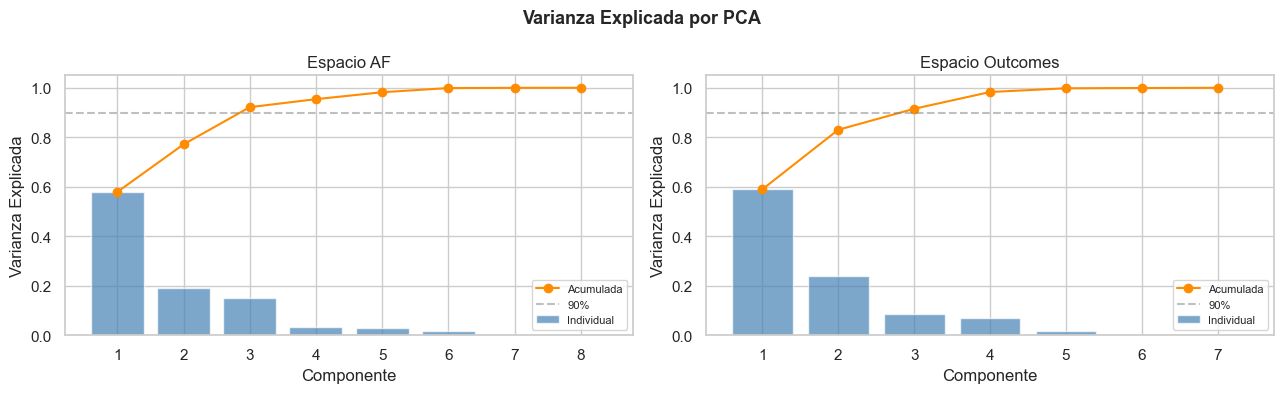

In [11]:
# ── PCA: varianza explicada ──────────────────────────────────────────────
pca_af = PCA().fit(X_af)
pca_out = PCA().fit(X_out)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Varianza Explicada por PCA", fontsize=13, fontweight="bold")

for ax, pca, title, n_feat in zip(
    axes, [pca_af, pca_out],
    ["Espacio AF", "Espacio Outcomes"],
    [len(AF_CONTINUAS), len(OUTCOME_FEATURES_FINAL)]
):
    cum_var = np.cumsum(pca.explained_variance_ratio_)
    ax.bar(range(1, n_feat + 1), pca.explained_variance_ratio_,
           alpha=0.7, color="steelblue", label="Individual")
    ax.plot(range(1, n_feat + 1), cum_var,
            "o-", color="darkorange", label="Acumulada")
    ax.axhline(0.9, ls="--", color="gray", alpha=0.5, label="90%")
    ax.set_xlabel("Componente")
    ax.set_ylabel("Varianza Explicada")
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

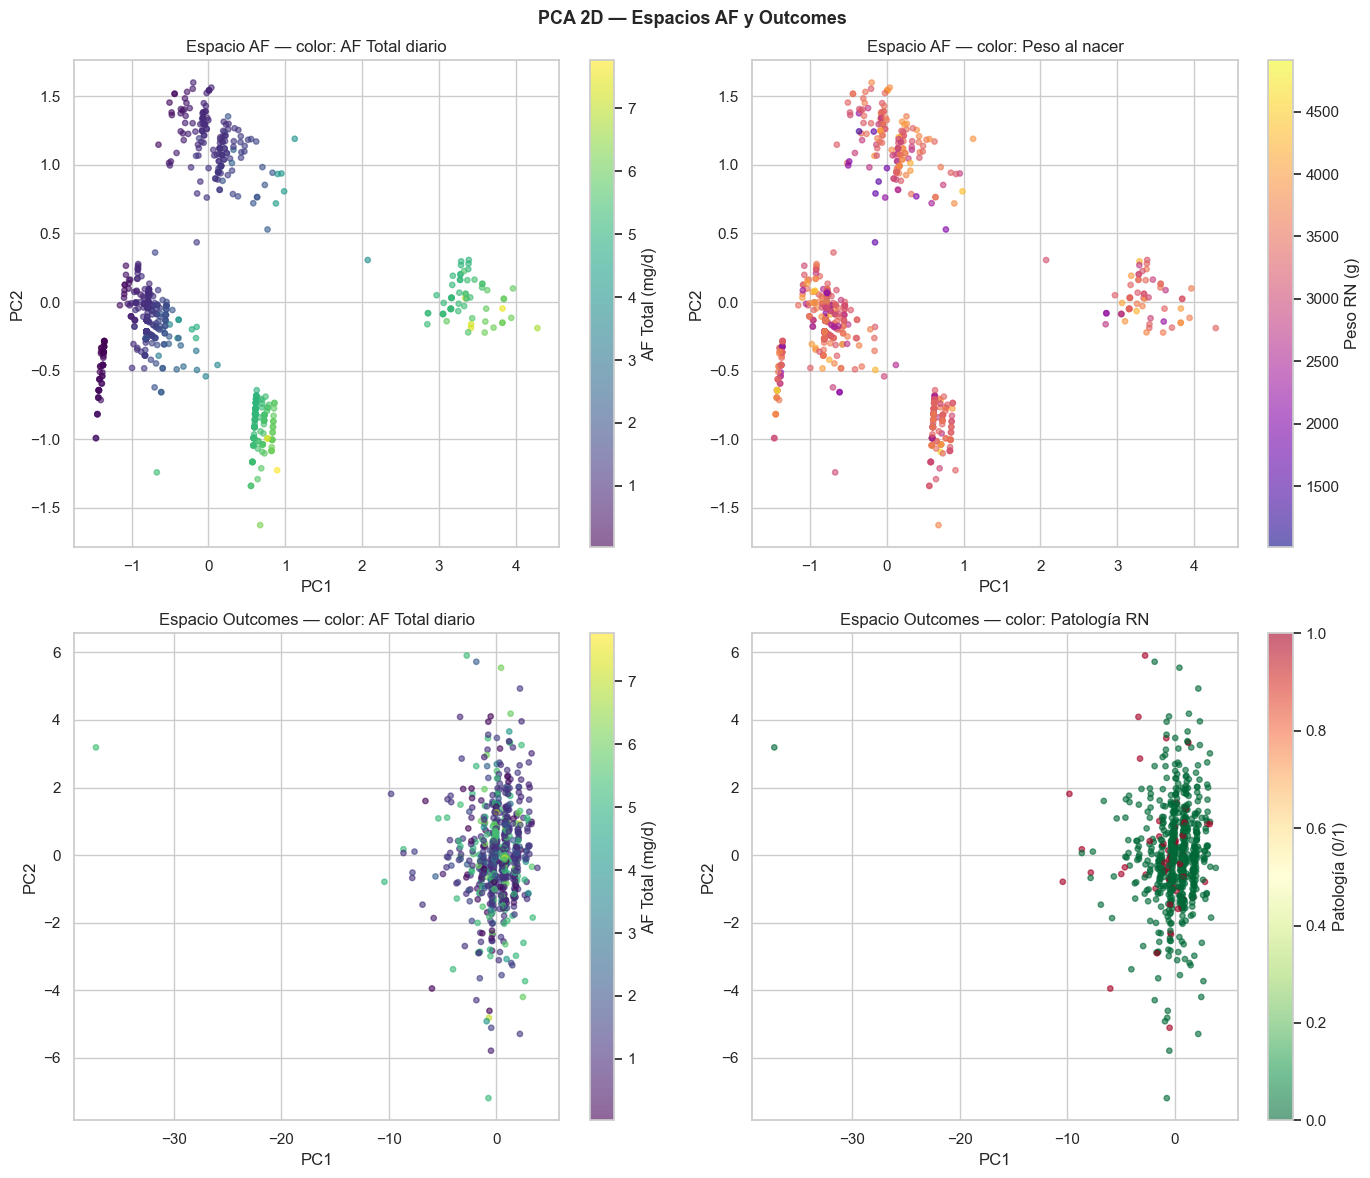

In [12]:
# ── PCA 2D: scatter coloreado ────────────────────────────────────────────
pca2d_af = PCA(n_components=2, random_state=42)
X_pca_af = pca2d_af.fit_transform(X_af)

pca2d_out = PCA(n_components=2, random_state=42)
X_pca_out = pca2d_out.fit_transform(X_out)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle("PCA 2D — Espacios AF y Outcomes", fontsize=13, fontweight="bold")

# AF coloreado por Total AF
sc = axes[0, 0].scatter(X_pca_af[:, 0], X_pca_af[:, 1],
                        c=df["Total mg/d AF  suple y pan"], cmap="viridis",
                        alpha=0.6, s=15)
plt.colorbar(sc, ax=axes[0, 0], label="AF Total (mg/d)")
axes[0, 0].set_title("Espacio AF — color: AF Total diario")

# AF coloreado por peso RN
sc = axes[0, 1].scatter(X_pca_af[:, 0], X_pca_af[:, 1],
                        c=df["PN hijo (g)"], cmap="plasma",
                        alpha=0.6, s=15)
plt.colorbar(sc, ax=axes[0, 1], label="Peso RN (g)")
axes[0, 1].set_title("Espacio AF — color: Peso al nacer")

# Outcomes coloreado por AF total
sc = axes[1, 0].scatter(X_pca_out[:, 0], X_pca_out[:, 1],
                        c=df["Total mg/d AF  suple y pan"], cmap="viridis",
                        alpha=0.6, s=15)
plt.colorbar(sc, ax=axes[1, 0], label="AF Total (mg/d)")
axes[1, 0].set_title("Espacio Outcomes — color: AF Total diario")

# Outcomes coloreado por problema de salud
sc = axes[1, 1].scatter(X_pca_out[:, 0], X_pca_out[:, 1],
                        c=df["hijo_con_patologia"], cmap="RdYlGn_r",
                        alpha=0.6, s=15)
plt.colorbar(sc, ax=axes[1, 1], label="Patología (0/1)")
axes[1, 1].set_title("Espacio Outcomes — color: Patología RN")

for ax in axes.flat:
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout()
plt.show()

c:\Users\Vivi\Documents\VS\escuela\tda_project\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\Vivi\Documents\VS\escuela\tda_project\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


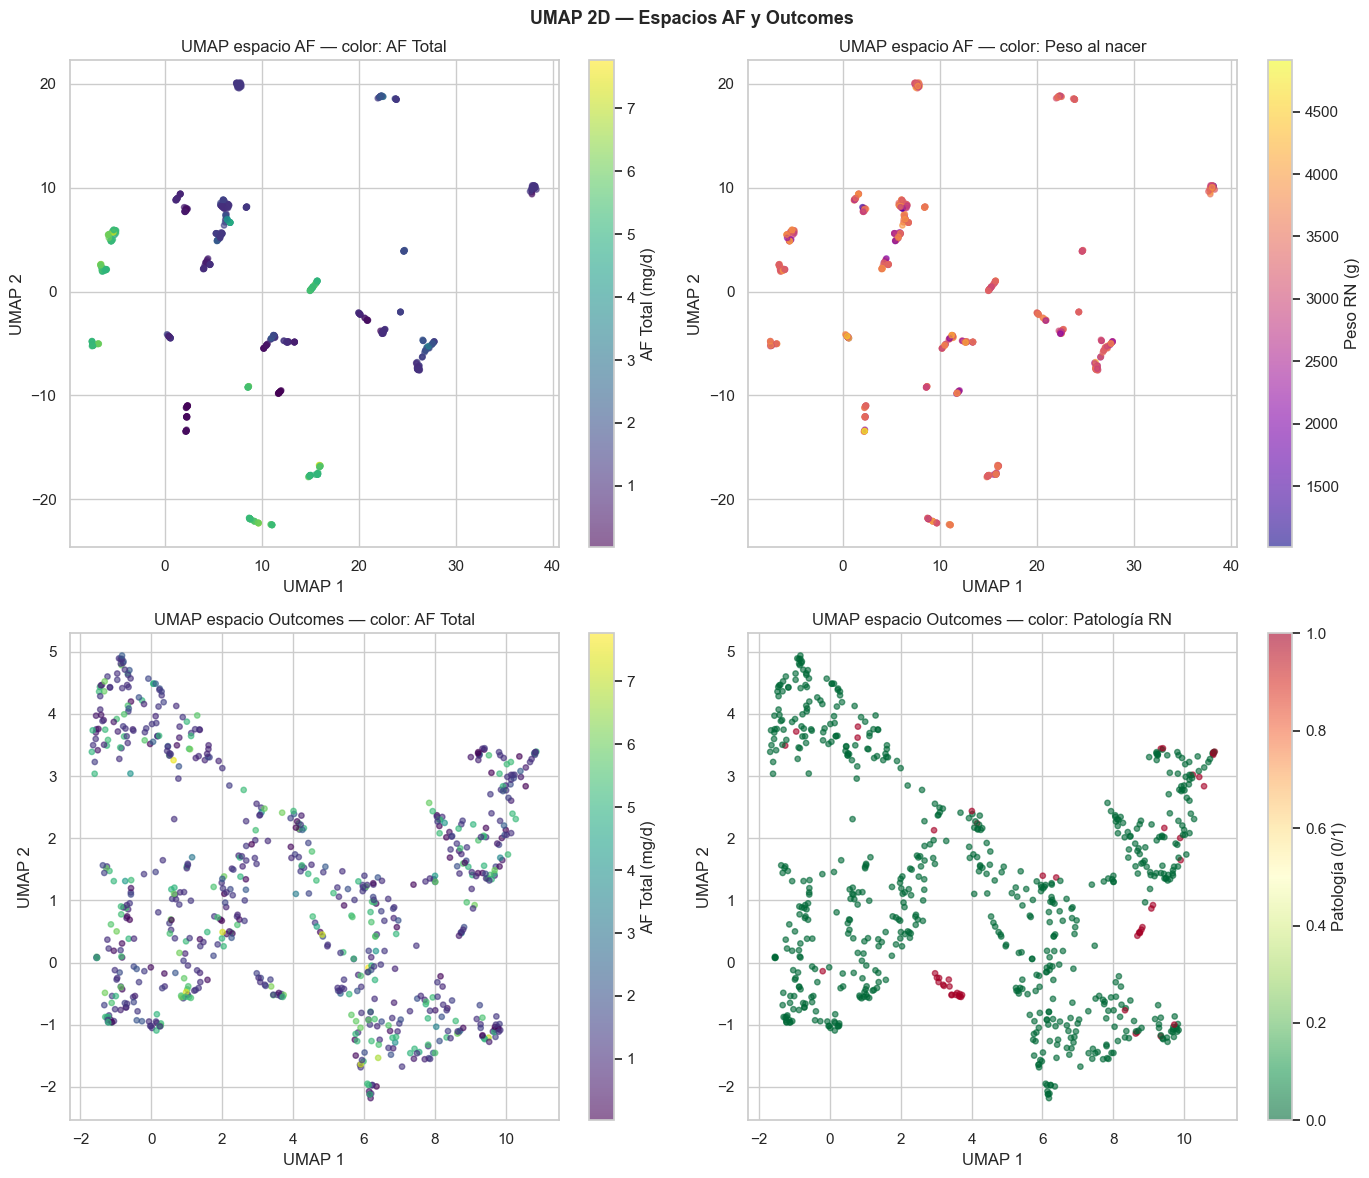

In [13]:
# ── UMAP 2D ──────────────────────────────────────────────────────────────
reducer_af = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                        metric="euclidean", random_state=42)
X_umap_af = reducer_af.fit_transform(X_af)

reducer_out = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                         metric="euclidean", random_state=42)
X_umap_out = reducer_out.fit_transform(X_out)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle("UMAP 2D — Espacios AF y Outcomes", fontsize=13, fontweight="bold")

# AF coloreado por Total AF
sc = axes[0, 0].scatter(X_umap_af[:, 0], X_umap_af[:, 1],
                        c=df["Total mg/d AF  suple y pan"], cmap="viridis",
                        alpha=0.6, s=15)
plt.colorbar(sc, ax=axes[0, 0], label="AF Total (mg/d)")
axes[0, 0].set_title("UMAP espacio AF — color: AF Total")

# AF coloreado por peso RN
sc = axes[0, 1].scatter(X_umap_af[:, 0], X_umap_af[:, 1],
                        c=df["PN hijo (g)"], cmap="plasma",
                        alpha=0.6, s=15)
plt.colorbar(sc, ax=axes[0, 1], label="Peso RN (g)")
axes[0, 1].set_title("UMAP espacio AF — color: Peso al nacer")

# Outcomes coloreado por AF total
sc = axes[1, 0].scatter(X_umap_out[:, 0], X_umap_out[:, 1],
                        c=df["Total mg/d AF  suple y pan"], cmap="viridis",
                        alpha=0.6, s=15)
plt.colorbar(sc, ax=axes[1, 0], label="AF Total (mg/d)")
axes[1, 0].set_title("UMAP espacio Outcomes — color: AF Total")

# Outcomes coloreado por problema de salud
sc = axes[1, 1].scatter(X_umap_out[:, 0], X_umap_out[:, 1],
                        c=df["hijo_con_patologia"], cmap="RdYlGn_r",
                        alpha=0.6, s=15)
plt.colorbar(sc, ax=axes[1, 1], label="Patología (0/1)")
axes[1, 1].set_title("UMAP espacio Outcomes — color: Patología RN")

for ax in axes.flat:
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")

plt.tight_layout()
plt.show()

## 5. Clustering clásico — baseline

K-Means y Ward sobre el espacio AF como referencia para comparar con Mapper.

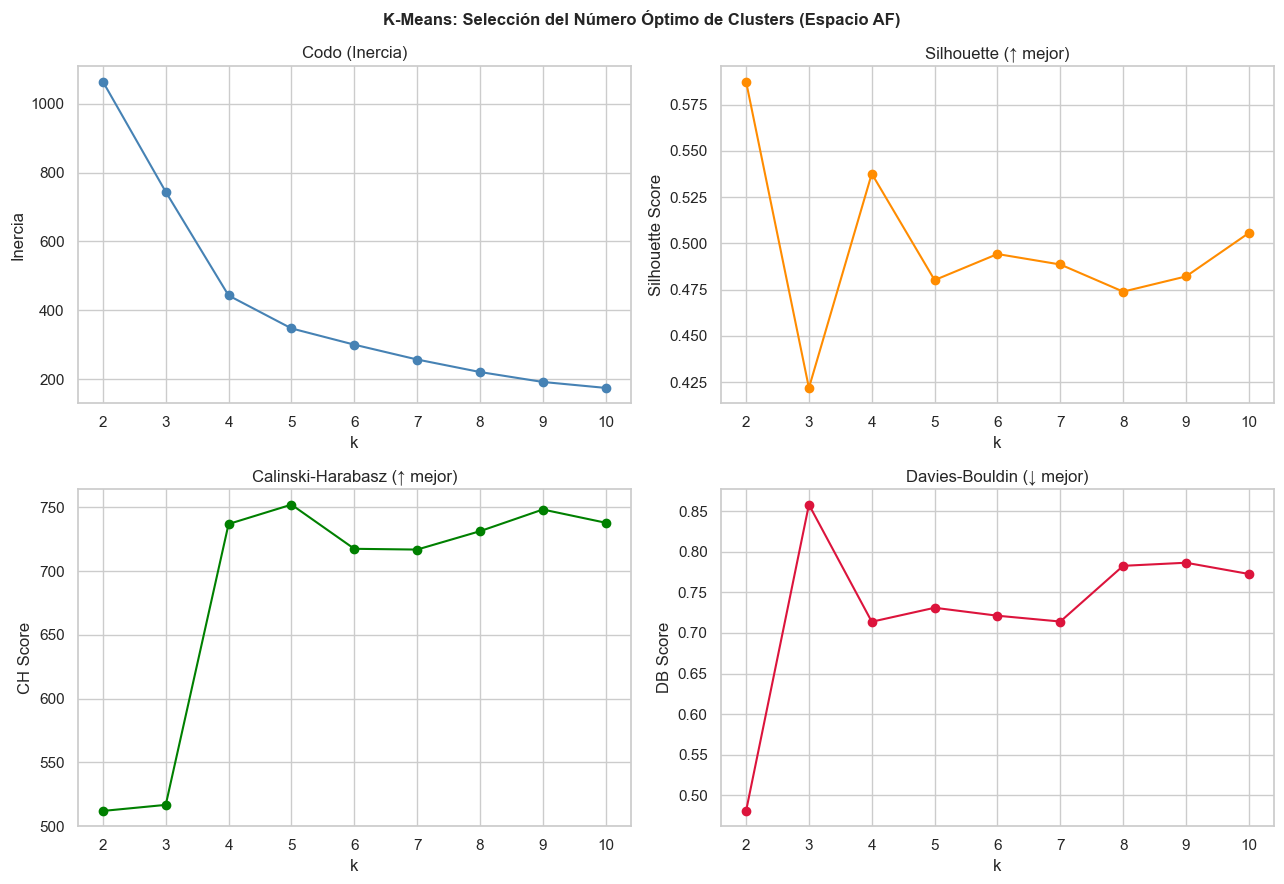

In [14]:
# ── K-Means: selección de k ─────────────────────────────────────────────
k_range = range(2, 11)
inertias, silhouettes, ch_scores, db_scores = [], [], [], []

for k in k_range:
    km_model = KMeans(n_clusters=k, random_state=42, n_init=15)
    labels = km_model.fit_predict(X_af)
    inertias.append(km_model.inertia_)
    silhouettes.append(silhouette_score(X_af, labels))
    ch_scores.append(calinski_harabasz_score(X_af, labels))
    db_scores.append(davies_bouldin_score(X_af, labels))

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("K-Means: Selección del Número Óptimo de Clusters (Espacio AF)",
             fontsize=12, fontweight="bold")

axes[0, 0].plot(k_range, inertias, "o-", color="steelblue")
axes[0, 0].set_title("Codo (Inercia)")
axes[0, 0].set_ylabel("Inercia")

axes[0, 1].plot(k_range, silhouettes, "o-", color="darkorange")
axes[0, 1].set_title("Silhouette (↑ mejor)")
axes[0, 1].set_ylabel("Silhouette Score")

axes[1, 0].plot(k_range, ch_scores, "o-", color="green")
axes[1, 0].set_title("Calinski-Harabasz (↑ mejor)")
axes[1, 0].set_ylabel("CH Score")

axes[1, 1].plot(k_range, db_scores, "o-", color="crimson")
axes[1, 1].set_title("Davies-Bouldin (↓ mejor)")
axes[1, 1].set_ylabel("DB Score")

for ax in axes.flat:
    ax.set_xlabel("k")

plt.tight_layout()
plt.show()

In [15]:
print(np.argmax(silhouettes))
print(k_range)

0
range(2, 11)


k óptimo (max Silhouette): 2
Adjusted Rand Index (K-Means vs Ward): 1.000


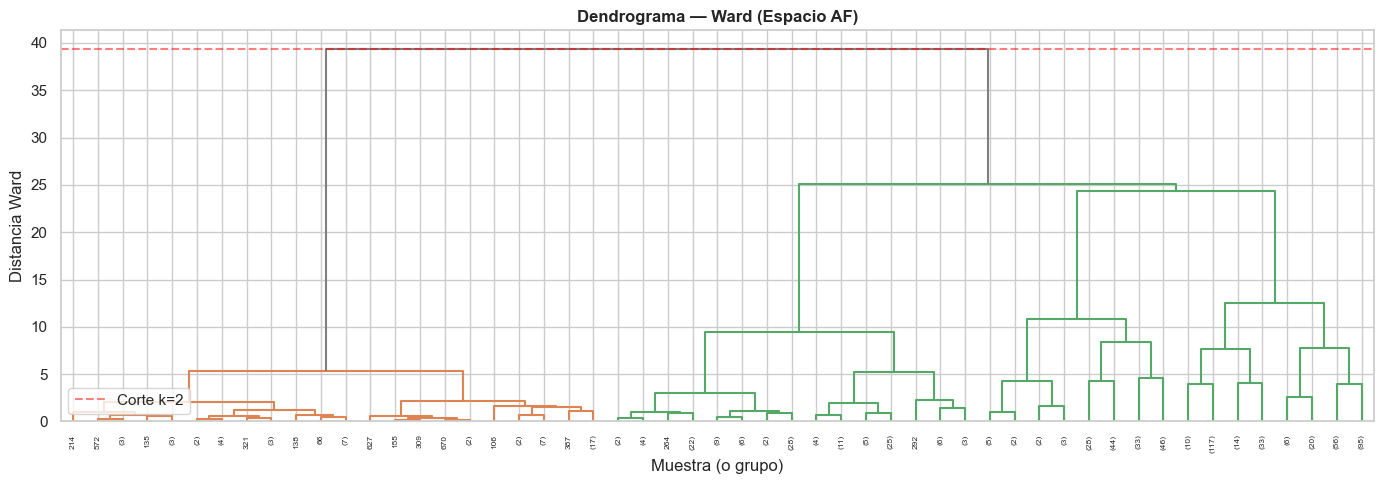

In [16]:
# ── K-Means: ajuste con k óptimo ────────────────────────────────────────
k_opt = 2
print(f"k óptimo (max Silhouette): {k_opt}")

km_final = KMeans(n_clusters=k_opt, random_state=42, n_init=15)
df["cluster_kmeans"] = km_final.fit_predict(X_af)

# ── Ward jerárquico ──────────────────────────────────────────────────────
linkage_matrix = linkage(X_af, method="ward", metric="euclidean")
df["cluster_ward"] = fcluster(linkage_matrix, t=k_opt, criterion="maxclust") - 1

# Acuerdo
ari = adjusted_rand_score(df["cluster_kmeans"], df["cluster_ward"])
print(f"Adjusted Rand Index (K-Means vs Ward): {ari:.3f}")

# %%
# ── Dendrograma Ward ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(linkage_matrix, truncate_mode="level", p=5,
           show_leaf_counts=True, ax=ax,
           color_threshold=linkage_matrix[-k_opt + 1, 2],
           above_threshold_color="gray")
ax.set_title("Dendrograma — Ward (Espacio AF)", fontsize=12, fontweight="bold")
ax.set_xlabel("Muestra (o grupo)")
ax.set_ylabel("Distancia Ward")
ax.axhline(linkage_matrix[-k_opt + 1, 2], color="red", ls="--", alpha=0.5,
           label=f"Corte k={k_opt}")
ax.legend()
plt.tight_layout()
plt.show()

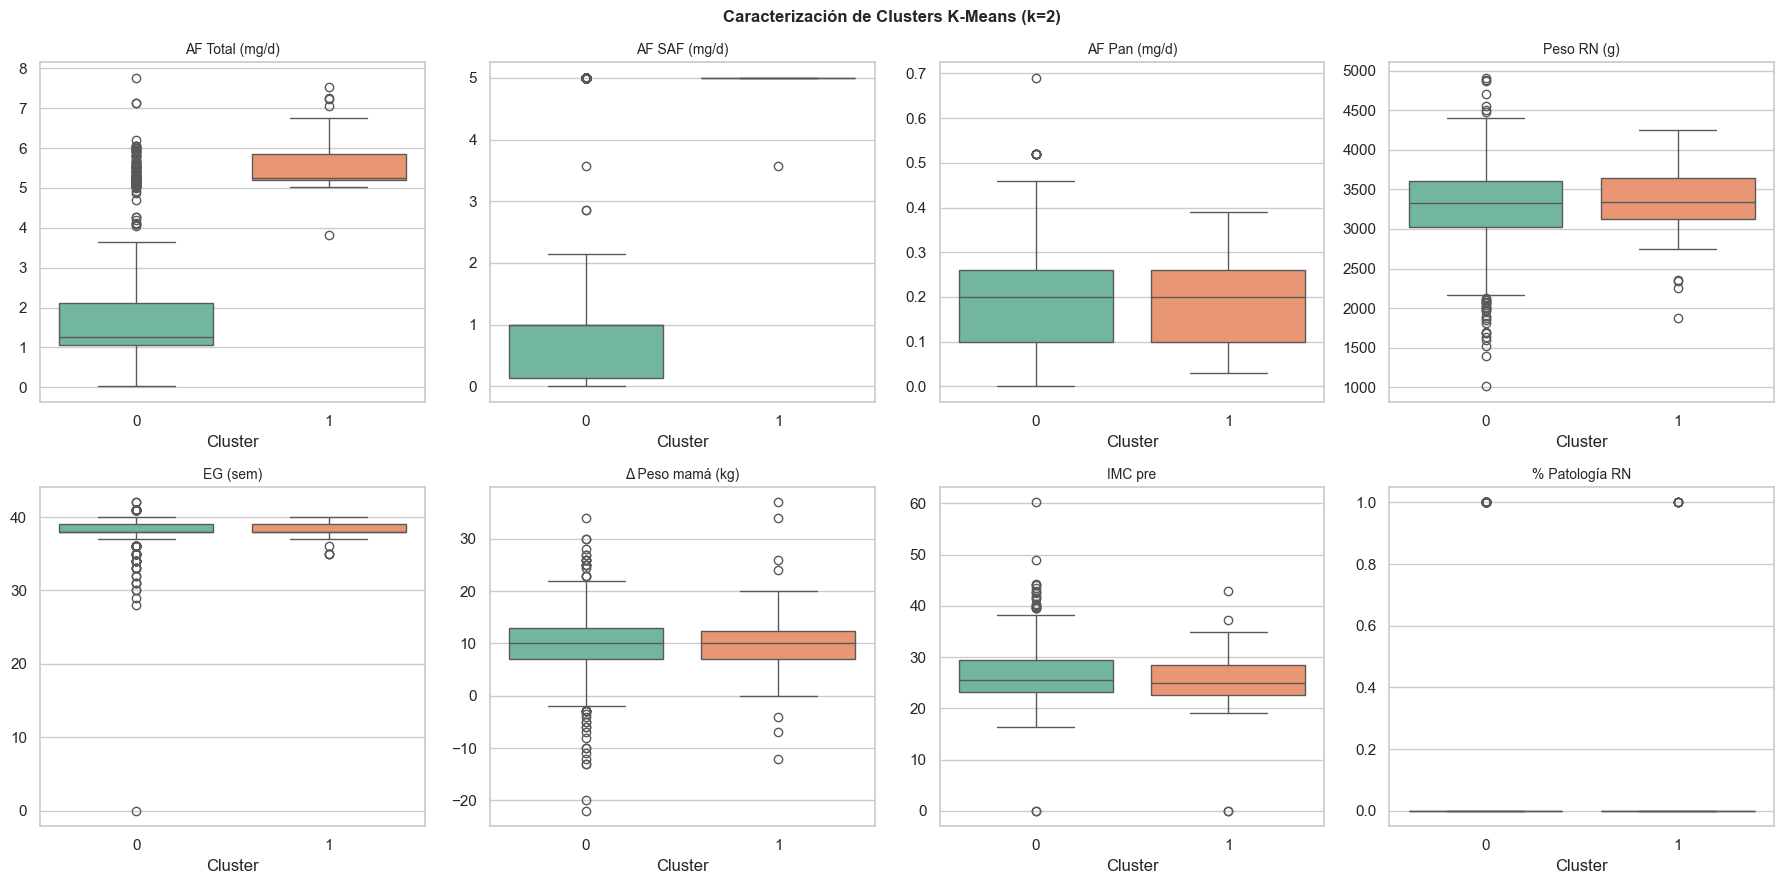


=== Mediana por cluster ===
                AF Total (mg/d)  AF SAF (mg/d)  AF Pan (mg/d)  Peso RN (g)  EG (sem)  Δ Peso mamá (kg)  IMC pre  % Patología RN
cluster_kmeans                                                                                                                 
0                          1.26            1.0            0.2       3330.0      38.0              10.0    25.48             0.0
1                          5.26            5.0            0.2       3335.0      38.0              10.0    24.90             0.0


In [17]:
# ── Caracterización de clusters por outcomes ─────────────────────────────
vars_resumen = [
    ("Total mg/d AF  suple y pan", "AF Total (mg/d)"),
    ("mgAF/día SAF", "AF SAF (mg/d)"),
    ("mg/d AF total pan", "AF Pan (mg/d)"),
    ("PN hijo (g)", "Peso RN (g)"),
    ("EG hijo (sem)", "EG (sem)"),
    ("Dif peso mamá", "Δ Peso mamá (kg)"),
    ("IMC antes", "IMC pre"),
    ("hijo_con_patologia", "% Patología RN"),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle(f"Caracterización de Clusters K-Means (k={k_opt})",
             fontsize=12, fontweight="bold")
axes = axes.flatten()

for i, (col, label) in enumerate(vars_resumen):
    if i >= len(axes):
        break
    sns.boxplot(data=df, x="cluster_kmeans", y=col, ax=axes[i],
                palette="Set2", hue="cluster_kmeans", legend=False)
    axes[i].set_title(label, fontsize=10)
    axes[i].set_xlabel(f"Cluster")
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

# Tabla resumen
print("\n=== Mediana por cluster ===")
resumen = df.groupby("cluster_kmeans")[[c for c, _ in vars_resumen]].median().round(2)
resumen.columns = [l for _, l in vars_resumen]
print(resumen.to_string())

## 6. Mapper con lente AF → datos de Outcomes

**Diseño:** La lente captura el patrón de consumo de AF (dónde está cada mujer
en el gradiente de AF). Los datos son el espacio de outcomes. Así el grafo
muestra cómo se organizan los resultados de salud a lo largo del gradiente de AF.

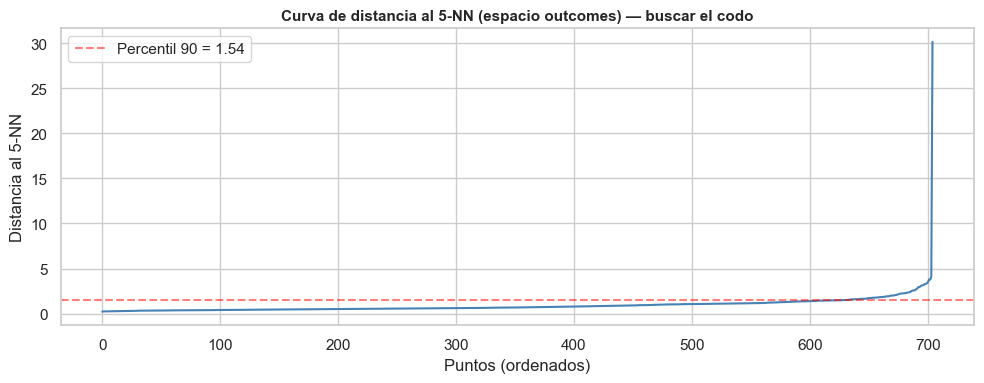

eps sugerido (percentil 75 de 5-NN dist): 1.11


In [18]:
# ── Búsqueda de eps para DBSCAN ──────────────────────────────────────────
# Se busca el "codo" en la curva de distancia al k-ésimo vecino más cercano
# sobre el espacio de outcomes (que es donde DBSCAN clusteriza dentro del Mapper)

k_nn = 5
nn = NearestNeighbors(n_neighbors=k_nn, metric="euclidean")
nn.fit(X_out)
distances, _ = nn.kneighbors(X_out)
k_dist = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(k_dist, color="steelblue")
ax.set_title(f"Curva de distancia al {k_nn}-NN (espacio outcomes) — buscar el codo",
             fontsize=11, fontweight="bold")
ax.set_xlabel("Puntos (ordenados)")
ax.set_ylabel(f"Distancia al {k_nn}-NN")
ax.axhline(np.percentile(k_dist, 90), color="red", ls="--", alpha=0.5,
           label=f"Percentil 90 = {np.percentile(k_dist, 90):.2f}")
ax.legend()
plt.tight_layout()
plt.show()

# Usar percentil 75 como eps sugerido
eps_sugerido = round(np.percentile(k_dist, 75), 2)
print(f"eps sugerido (percentil 75 de {k_nn}-NN dist): {eps_sugerido}")

In [19]:
# ── Funciones auxiliares para Mapper ─────────────────────────────────────

def calcular_stats_nodos(graph, df_ref, var_color, var_stats):
    """Calcula estadísticas por nodo del Mapper."""
    node_stats = []
    for node_id, member_ids in graph["nodes"].items():
        subset = df_ref.iloc[member_ids]
        stats = {
            "Nodo": node_id,
            "N miembros": len(member_ids),
        }
        for var, nombre in var_stats:
            if var in subset.columns:
                stats[nombre] = subset[var].median()
        node_stats.append(stats)
    return pd.DataFrame(node_stats)


def plot_mapper_graph(graph, df_ref, color_var, color_label, title,
                      cmap="viridis", figsize=(12, 9)):
    """Visualización estática del grafo Mapper con networkx."""
    G = nx.Graph()

    # Nodos: tamaño proporcional a membresía, color por mediana de la variable
    node_sizes = {}
    node_colors = {}
    for node_id, member_ids in graph["nodes"].items():
        G.add_node(node_id)
        node_sizes[node_id] = len(member_ids)
        node_colors[node_id] = df_ref.iloc[member_ids][color_var].median()

    # Aristas
    for node_id, neighbors in graph["links"].items():
        for nb in neighbors:
            G.add_edge(node_id, nb)

    if len(G.nodes) == 0:
        print("⚠️  El grafo Mapper no tiene nodos. Ajustar hiperparámetros.")
        return

    pos = nx.spring_layout(G, seed=42, k=0.5)

    fig, ax = plt.subplots(figsize=figsize)

    # Dibujar aristas
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.3, width=0.8)

    # Dibujar nodos
    ordered_nodes = list(G.nodes)
    sizes = [node_sizes[n] * 15 for n in ordered_nodes]
    colors = [node_colors[n] for n in ordered_nodes]

    sc = ax.scatter(
        [pos[n][0] for n in ordered_nodes],
        [pos[n][1] for n in ordered_nodes],
        c=colors, cmap=cmap, s=sizes, edgecolors="black",
        linewidths=0.5, alpha=0.85, zorder=5
    )
    plt.colorbar(sc, ax=ax, label=color_label, shrink=0.8)

    n_nodes = len(graph["nodes"])
    n_edges = sum(len(v) for v in graph["links"].values()) // 2
    ax.set_title(f"{title}\n({n_nodes} nodos, {n_edges} aristas)",
                 fontsize=12, fontweight="bold")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

    return G

In [20]:
# ── Mapper 1A: lente = AF Total (1D), datos = outcomes ──────────────────

mapper_obj = km.KeplerMapper(verbose=0)

# Lente 1D: Total AF diario (escalado para Cover)
lens_af_1d = df["Total mg/d AF  suple y pan"].values.reshape(-1, 1)

# Grafo Mapper
graph_af_1d = mapper_obj.map(
    lens_af_1d,
    X_out,
    cover=Cover(n_cubes=15, perc_overlap=0.4),
    clusterer=DBSCAN(eps=eps_sugerido, min_samples=3),
)

n_nodos = len(graph_af_1d["nodes"])
n_aristas = sum(len(v) for v in graph_af_1d["links"].values()) // 2
print(f"Mapper AF 1D → Outcomes:")
print(f"  Nodos: {n_nodos}, Aristas: {n_aristas}")

if n_nodos == 0:
    print("⚠️  Grafo vacío. Prueba ajustar eps o n_cubes.")

Mapper AF 1D → Outcomes:
  Nodos: 22, Aristas: 7


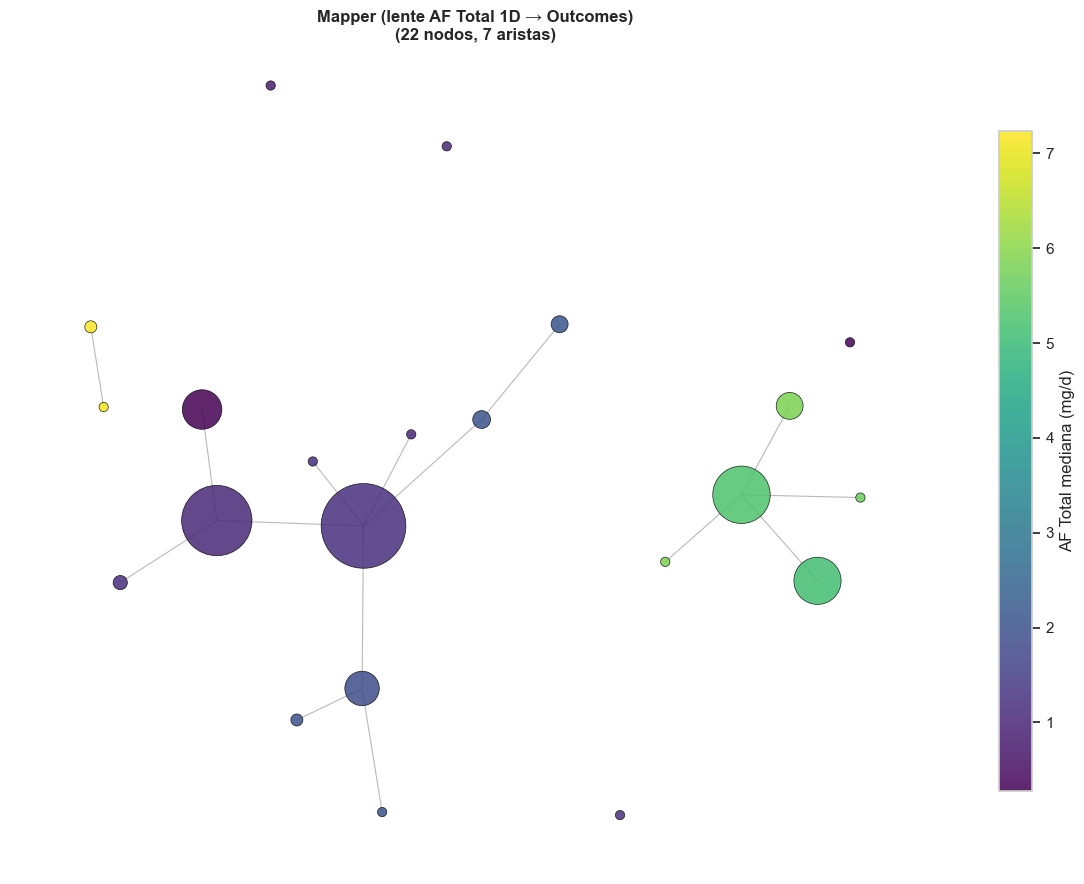

In [21]:
# ── Visualización Mapper 1A: colorear por AF Total ───────────────────────
G_af1d = plot_mapper_graph(
    graph_af_1d, df,
    color_var="Total mg/d AF  suple y pan",
    color_label="AF Total mediana (mg/d)",
    title="Mapper (lente AF Total 1D → Outcomes)",
    cmap="viridis"
)

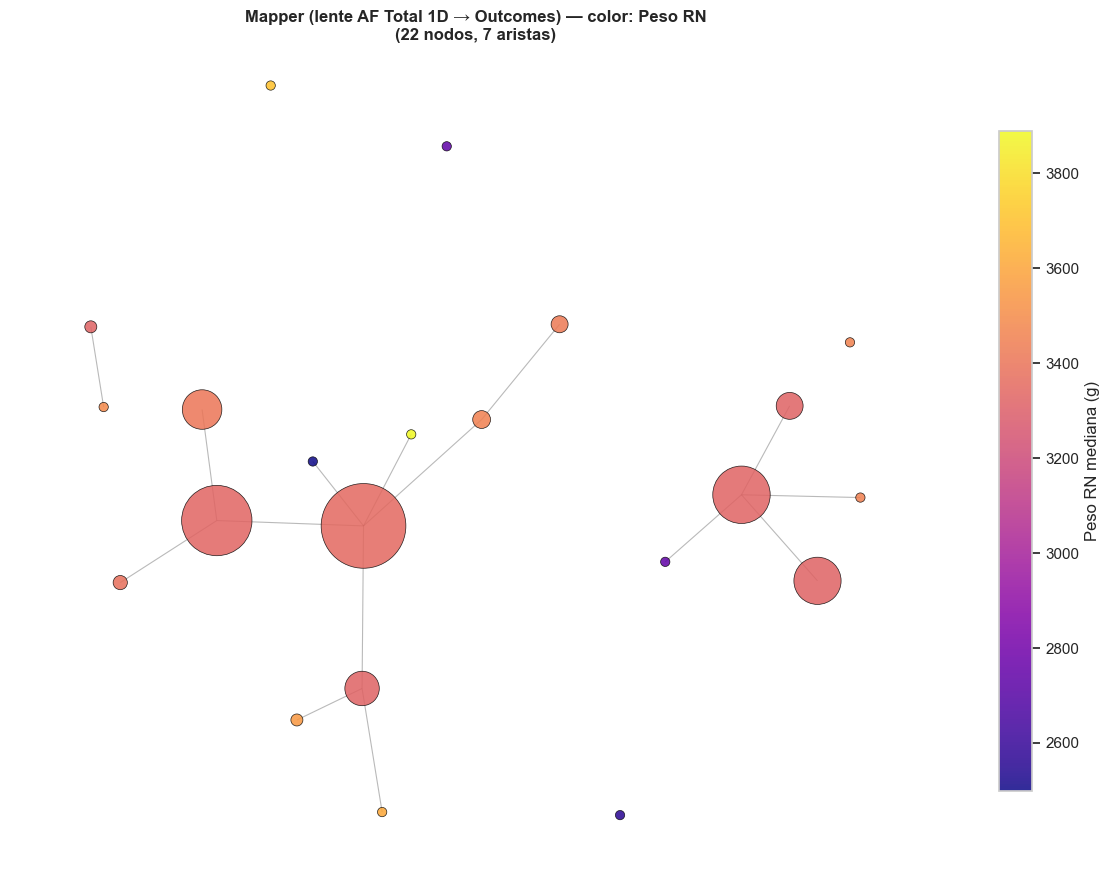

In [22]:
# ── Visualización Mapper 1A: colorear por Peso RN ────────────────────────
plot_mapper_graph(
    graph_af_1d, df,
    color_var="PN hijo (g)",
    color_label="Peso RN mediana (g)",
    title="Mapper (lente AF Total 1D → Outcomes) — color: Peso RN",
    cmap="plasma"
)

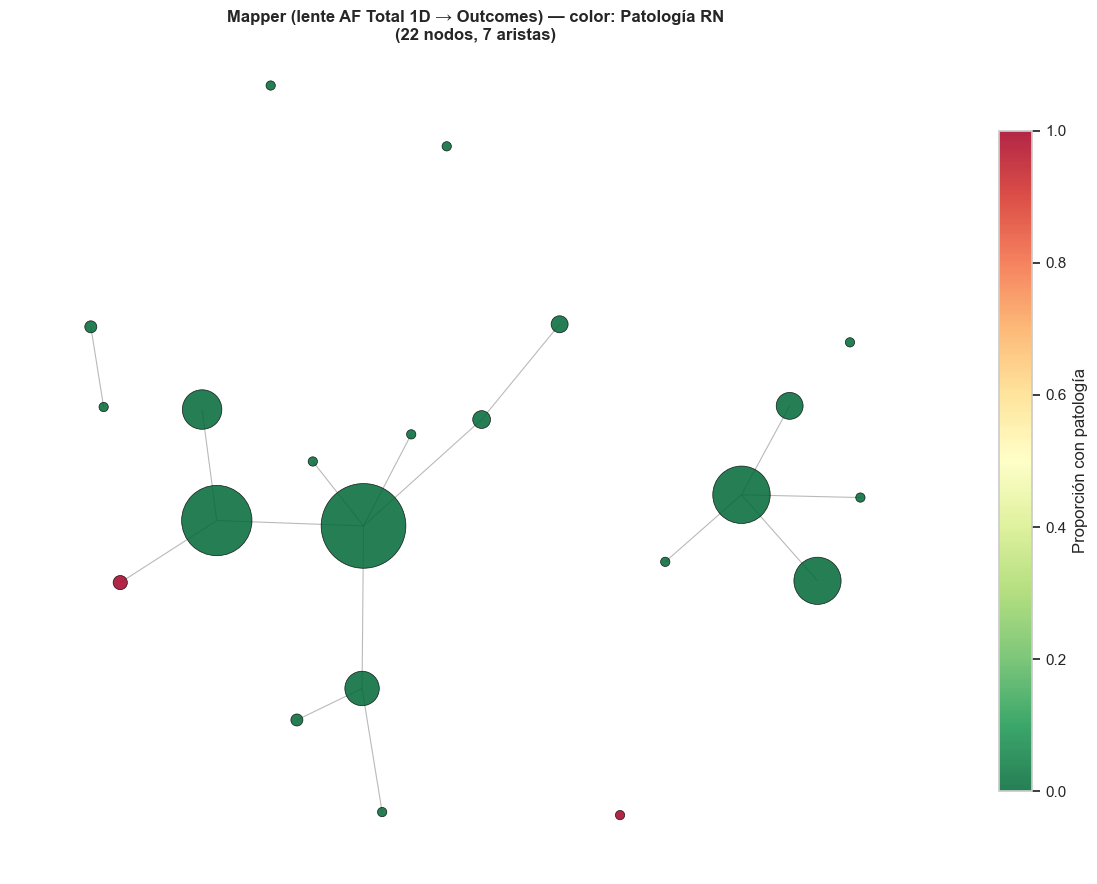

In [23]:
# ── Visualización Mapper 1A: colorear por Patología ──────────────────────
plot_mapper_graph(
    graph_af_1d, df,
    color_var="hijo_con_patologia",
    color_label="Proporción con patología",
    title="Mapper (lente AF Total 1D → Outcomes) — color: Patología RN",
    cmap="RdYlGn_r"
)

In [24]:
# ── Estadísticas por nodo — Mapper 1A ────────────────────────────────────
stats_vars = [
    ("Total mg/d AF  suple y pan", "AF Total med. (mg/d)"),
    ("mgAF/día SAF", "AF SAF med. (mg/d)"),
    ("PN hijo (g)", "Peso RN med. (g)"),
    ("EG hijo (sem)", "EG med. (sem)"),
    ("Dif peso mamá", "ΔPeso mamá med."),
    ("hijo_con_patologia", "% Patología"),
    ("Edad madre", "Edad med."),
    ("IMC antes", "IMC pre med."),
]

df_stats_af1d = calcular_stats_nodos(graph_af_1d, df, "Total mg/d AF  suple y pan", stats_vars)
print("=== Nodos con mayor % de patología RN ===")
print(df_stats_af1d.sort_values("% Patología", ascending=False).head(8).to_string(index=False))
print()
print("=== Nodos con mayor AF total ===")
print(df_stats_af1d.sort_values("AF Total med. (mg/d)", ascending=False).head(5).to_string(index=False))


=== Nodos con mayor % de patología RN ===
          Nodo  N miembros  AF Total med. (mg/d)  AF SAF med. (mg/d)  Peso RN med. (g)  EG med. (sem)  ΔPeso mamá med.  % Patología  Edad med.  IMC pre med.
cube2_cluster3           3                 1.260                 1.0            2560.0           38.0              9.0          1.0       35.0         26.45
cube2_cluster1           7                 1.200                 1.0            3380.0           39.0             14.0          1.0       33.0         24.91
cube1_cluster0         171                 1.060                 1.0            3335.0           39.0             10.0          0.0       34.0         25.00
cube1_cluster1           3                 1.200                 1.0            2498.0           35.0              9.0          0.0       30.0         25.63
cube0_cluster0          54                 0.273                 0.0            3407.5           39.0              9.0          0.0       35.0         24.80
cube0_cluster1  

### Mapper 1B: lente = UMAP del espacio AF (2D)

La lente 2D captura más estructura que la 1D, pero es menos interpretable.

In [25]:
# ── Mapper 1B: lente = UMAP AF (2D), datos = outcomes ───────────────────
lens_af_2d = X_umap_af  # Ya calculado arriba

graph_af_2d = mapper_obj.map(
    lens_af_2d,
    X_out,
    cover=Cover(n_cubes=12, perc_overlap=0.4),
    clusterer=DBSCAN(eps=eps_sugerido, min_samples=3),
)

n_nodos_2d = len(graph_af_2d["nodes"])
n_aristas_2d = sum(len(v) for v in graph_af_2d["links"].values()) // 2
print(f"Mapper AF 2D (UMAP) → Outcomes:")
print(f"  Nodos: {n_nodos_2d}, Aristas: {n_aristas_2d}")

Mapper AF 2D (UMAP) → Outcomes:
  Nodos: 83, Aristas: 49


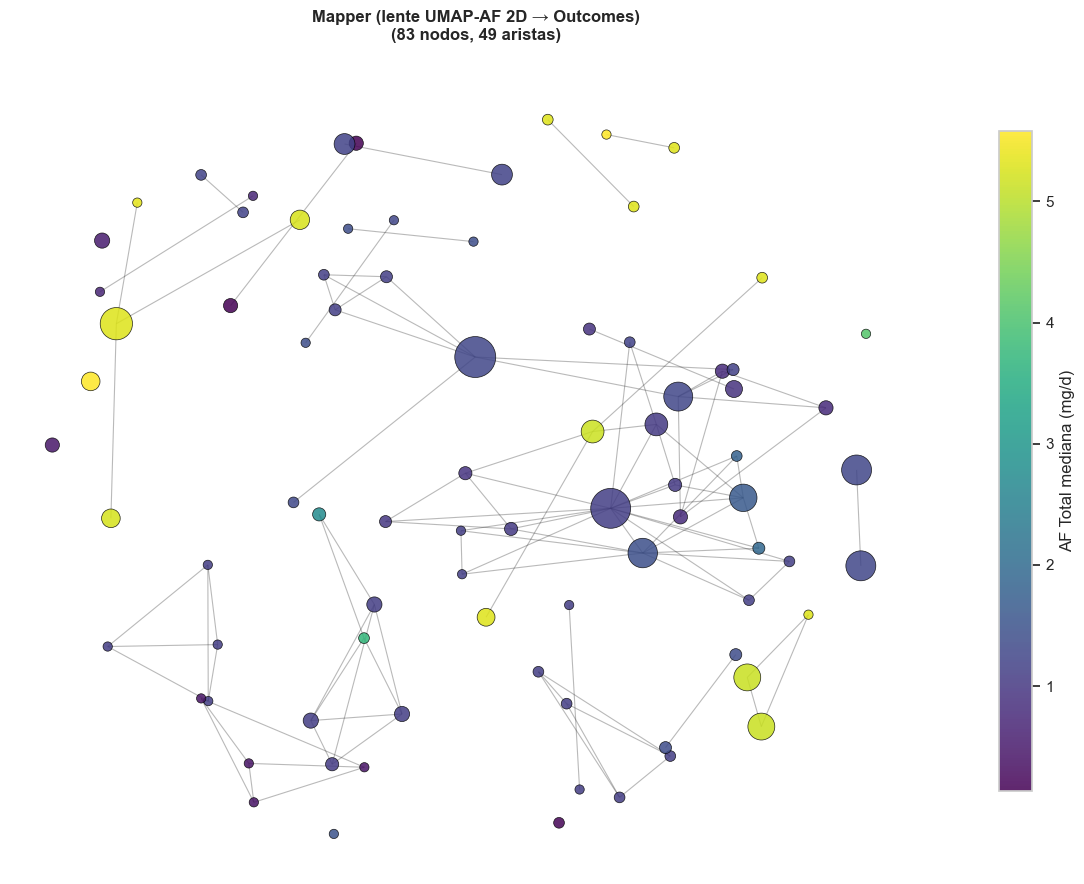

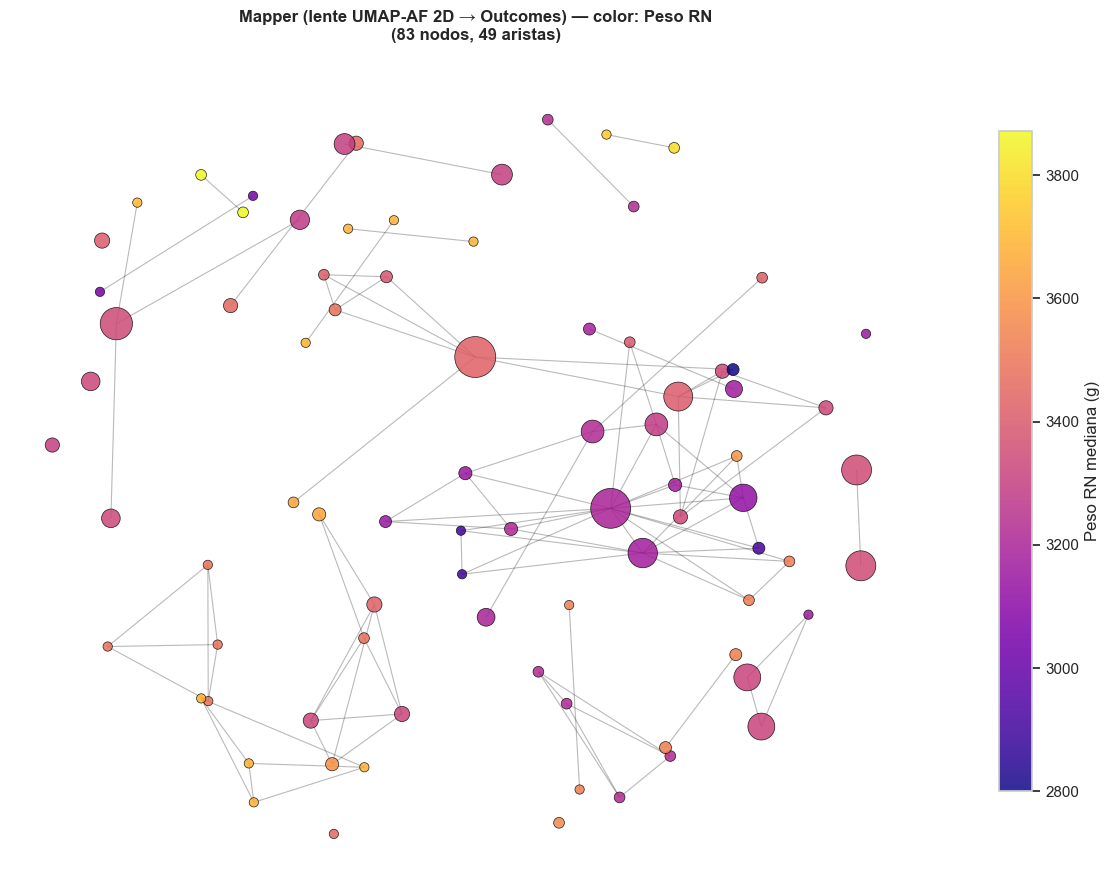

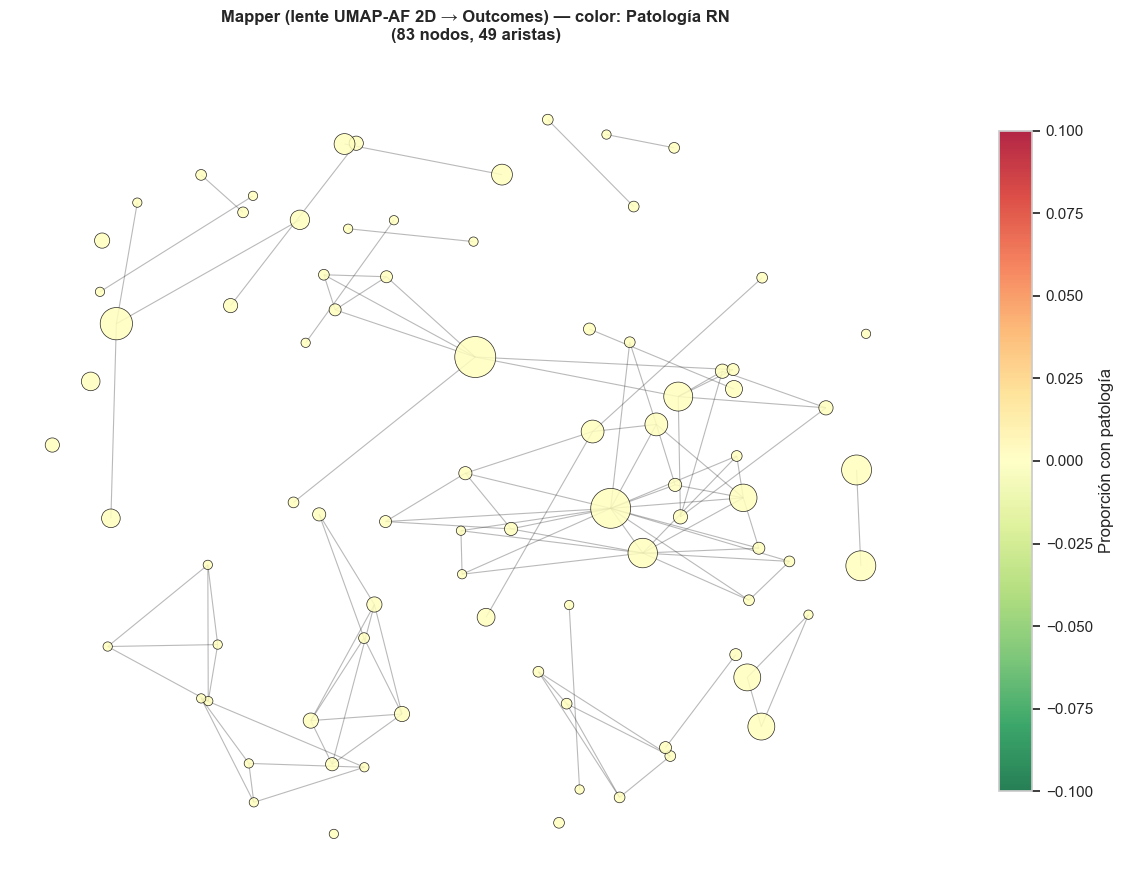

=== Mapper 1B — Nodos con mayor % de patología RN ===
          Nodo  N miembros  AF Total med. (mg/d)  AF SAF med. (mg/d)  Peso RN med. (g)  EG med. (sem)  ΔPeso mamá med.  % Patología  Edad med.  IMC pre med.
cube0_cluster0           4                5.3250                 5.0            3235.0           39.0            10.00          0.0       37.5        23.955
cube1_cluster0           4                5.3250                 5.0            3235.0           39.0            10.00          0.0       37.5        23.955
cube2_cluster0          12                5.2325                 5.0            3338.5           39.0            10.00          0.0       35.5        22.230
cube3_cluster0          36                5.2975                 5.0            3345.0           39.0            10.65          0.0       37.0        24.110
cube4_cluster0          13                5.2600                 5.0            3285.0           38.0            12.00          0.0       37.0        24.760
cube

In [26]:
# ── Visualización Mapper 1B ──────────────────────────────────────────────
plot_mapper_graph(
    graph_af_2d, df,
    color_var="Total mg/d AF  suple y pan",
    color_label="AF Total mediana (mg/d)",
    title="Mapper (lente UMAP-AF 2D → Outcomes)",
    cmap="viridis"
)

plot_mapper_graph(
    graph_af_2d, df,
    color_var="PN hijo (g)",
    color_label="Peso RN mediana (g)",
    title="Mapper (lente UMAP-AF 2D → Outcomes) — color: Peso RN",
    cmap="plasma"
)

plot_mapper_graph(
    graph_af_2d, df,
    color_var="hijo_con_patologia",
    color_label="Proporción con patología",
    title="Mapper (lente UMAP-AF 2D → Outcomes) — color: Patología RN",
    cmap="RdYlGn_r"
)

# ── Estadísticas por nodo — Mapper 1B ────────────────────────────────────
df_stats_af2d = calcular_stats_nodos(graph_af_2d, df, "Total mg/d AF  suple y pan", stats_vars)
print("=== Mapper 1B — Nodos con mayor % de patología RN ===")
print(df_stats_af2d.sort_values("% Patología", ascending=False).head(8).to_string(index=False))

## 7. Mapper con lente Outcomes → datos de AF

Ahora el Mapper usa los outcomes como lente y el espacio AF como datos.
Esto muestra: "¿Cómo se organizan los patrones de consumo de AF entre
mujeres con resultados de salud similares?"

In [27]:
# ── Búsqueda de eps para espacio AF ──────────────────────────────────────
nn_af = NearestNeighbors(n_neighbors=k_nn, metric="euclidean")
nn_af.fit(X_af)
dist_af, _ = nn_af.kneighbors(X_af)
k_dist_af = np.sort(dist_af[:, -1])

eps_af = round(np.percentile(k_dist_af, 75), 2)
print(f"eps sugerido para espacio AF: {eps_af}")

eps sugerido para espacio AF: 0.2


In [28]:
# ── Mapper 2A: lente = Peso RN (1D), datos = AF ─────────────────────────
lens_out_1d = df["PN hijo (g)"].values.reshape(-1, 1)

graph_out_1d = mapper_obj.map(
    lens_out_1d,
    X_af,
    cover=Cover(n_cubes=15, perc_overlap=0.4),
    clusterer=DBSCAN(eps=eps_af, min_samples=3),
)

n_nodos = len(graph_out_1d["nodes"])
n_aristas = sum(len(v) for v in graph_out_1d["links"].values()) // 2
print(f"Mapper Peso RN 1D → AF:")
print(f"  Nodos: {n_nodos}, Aristas: {n_aristas}")

Mapper Peso RN 1D → AF:
  Nodos: 83, Aristas: 26


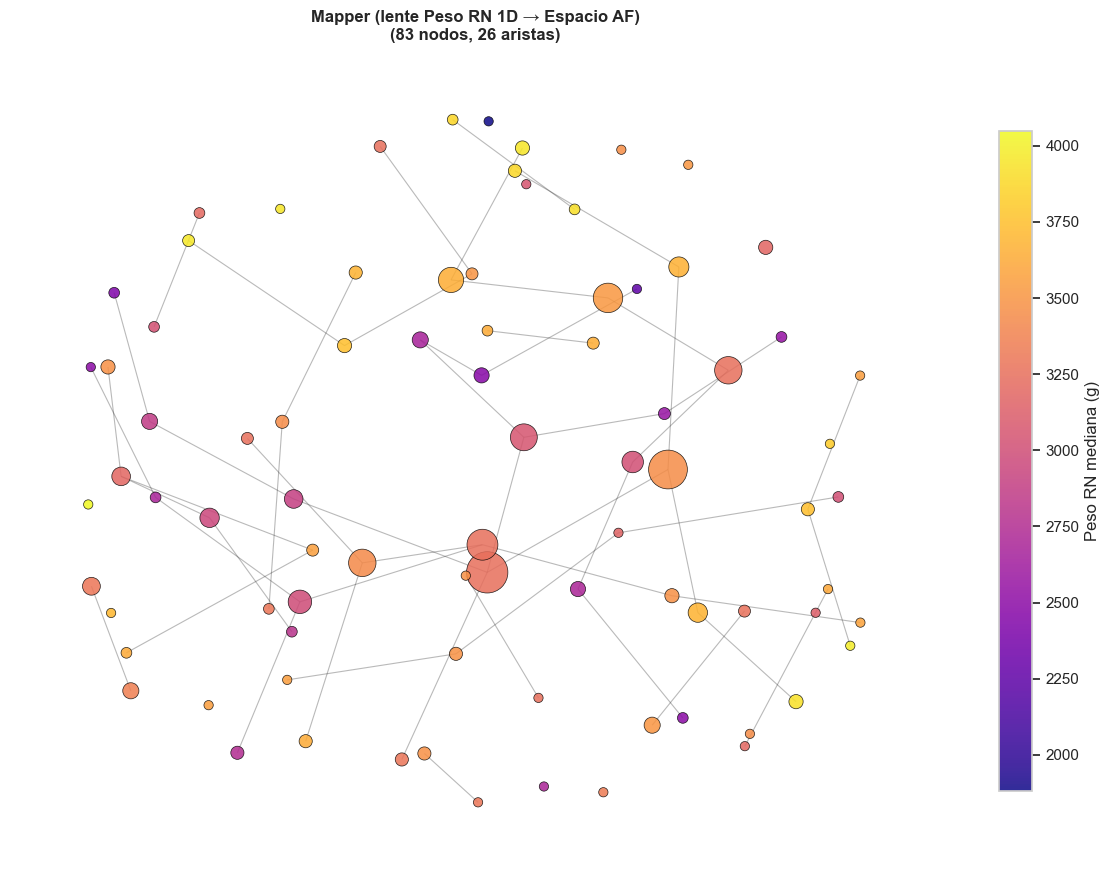

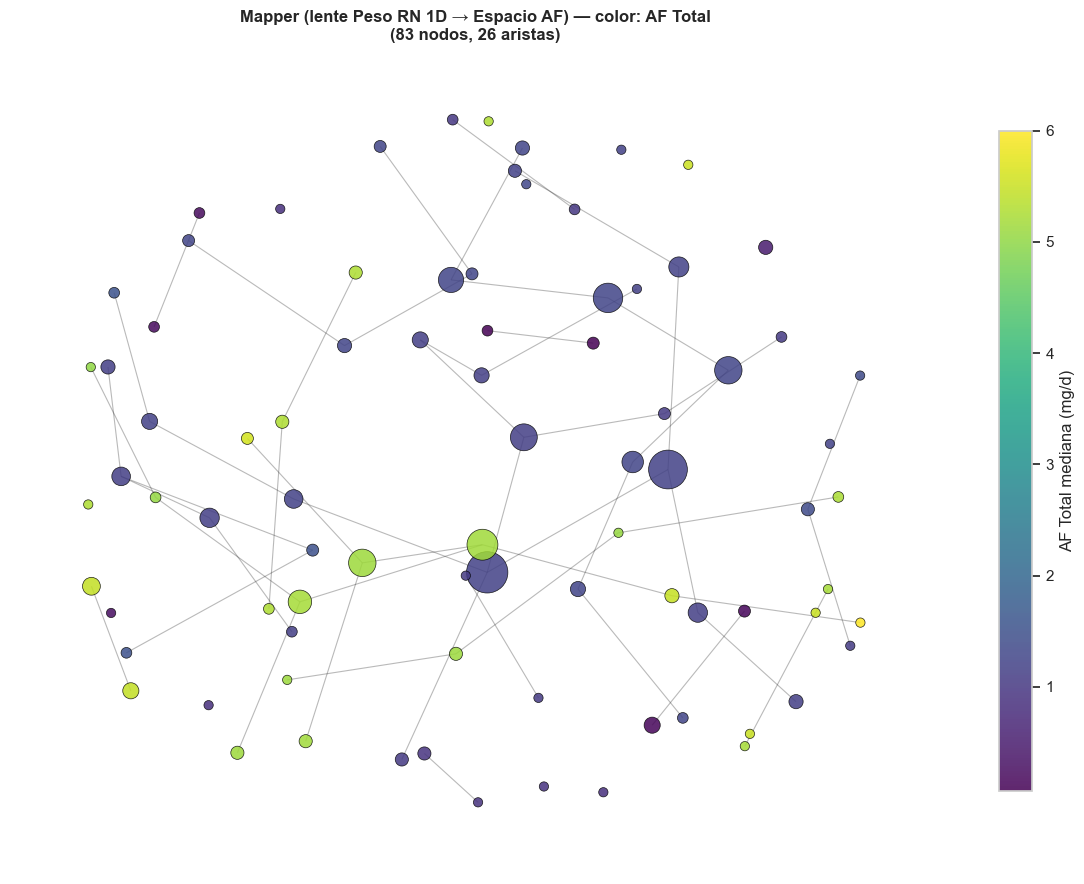

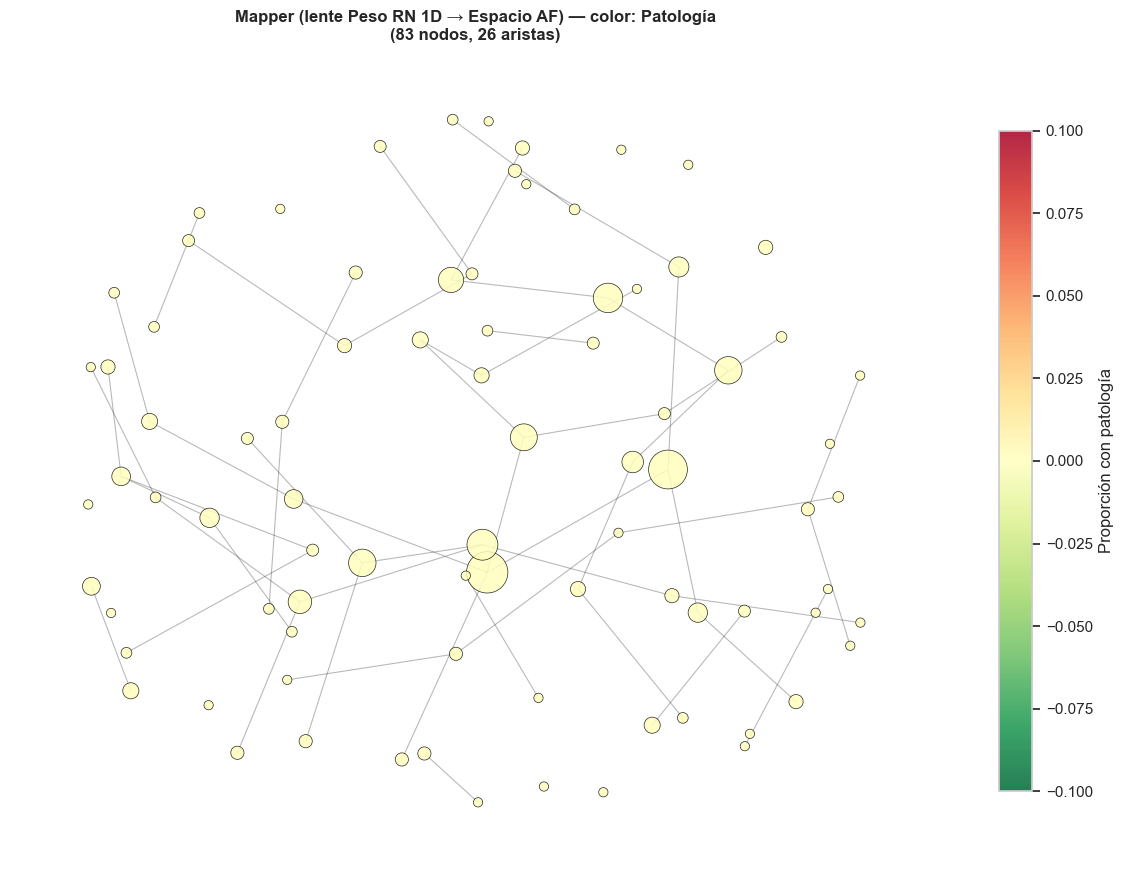

=== Mapper 2A — Nodos con menor peso RN ===
          Nodo  N miembros  AF Total med. (mg/d)  AF SAF med. (mg/d)  Peso RN med. (g)  EG med. (sem)  ΔPeso mamá med.  % Patología  Edad med.  IMC pre med.
cube3_cluster0           3                 5.260                 5.0            1880.0           33.0            11.00          0.0       36.0        26.810
cube4_cluster0           3                 1.160                 1.0            2250.0           38.0             8.00          0.0       33.0        26.990
cube5_cluster3           4                 1.535                 1.0            2430.0           36.0             7.75          0.0       33.5        25.875
cube5_cluster0           8                 1.130                 1.0            2472.0           38.0            10.50          0.0       33.5        23.860
cube5_cluster4           4                 1.260                 1.0            2495.0           35.5             8.75          0.0       33.5        26.810
cube5_cluster1

In [29]:
# ── Visualización Mapper 2A ──────────────────────────────────────────────
plot_mapper_graph(
    graph_out_1d, df,
    color_var="PN hijo (g)",
    color_label="Peso RN mediana (g)",
    title="Mapper (lente Peso RN 1D → Espacio AF)",
    cmap="plasma"
)

plot_mapper_graph(
    graph_out_1d, df,
    color_var="Total mg/d AF  suple y pan",
    color_label="AF Total mediana (mg/d)",
    title="Mapper (lente Peso RN 1D → Espacio AF) — color: AF Total",
    cmap="viridis"
)

plot_mapper_graph(
    graph_out_1d, df,
    color_var="hijo_con_patologia",
    color_label="Proporción con patología",
    title="Mapper (lente Peso RN 1D → Espacio AF) — color: Patología",
    cmap="RdYlGn_r"
)

# ── Estadísticas por nodo — Mapper 2A ────────────────────────────────────
df_stats_out1d = calcular_stats_nodos(graph_out_1d, df, "PN hijo (g)", stats_vars)
print("=== Mapper 2A — Nodos con menor peso RN ===")
print(df_stats_out1d.sort_values("Peso RN med. (g)").head(8).to_string(index=False))

In [30]:
# ── Mapper 2B: lente = UMAP Outcomes (2D), datos = AF ────────────────────
lens_out_2d = X_umap_out

graph_out_2d = mapper_obj.map(
    lens_out_2d,
    X_af,
    cover=Cover(n_cubes=12, perc_overlap=0.4),
    clusterer=DBSCAN(eps=eps_af, min_samples=3),
)

n_nodos_2d = len(graph_out_2d["nodes"])
n_aristas_2d = sum(len(v) for v in graph_out_2d["links"].values()) // 2
print(f"Mapper UMAP-Outcomes 2D → AF:")
print(f"  Nodos: {n_nodos_2d}, Aristas: {n_aristas_2d}")

Mapper UMAP-Outcomes 2D → AF:
  Nodos: 92, Aristas: 35


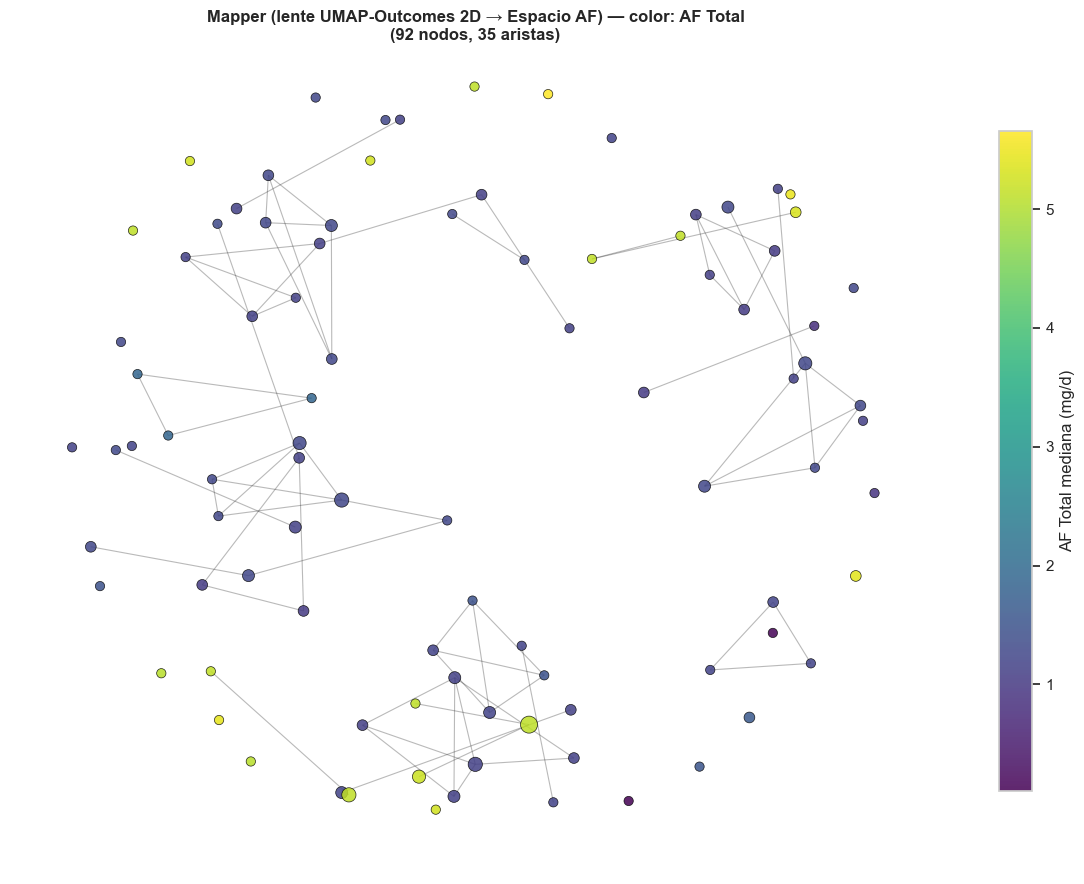

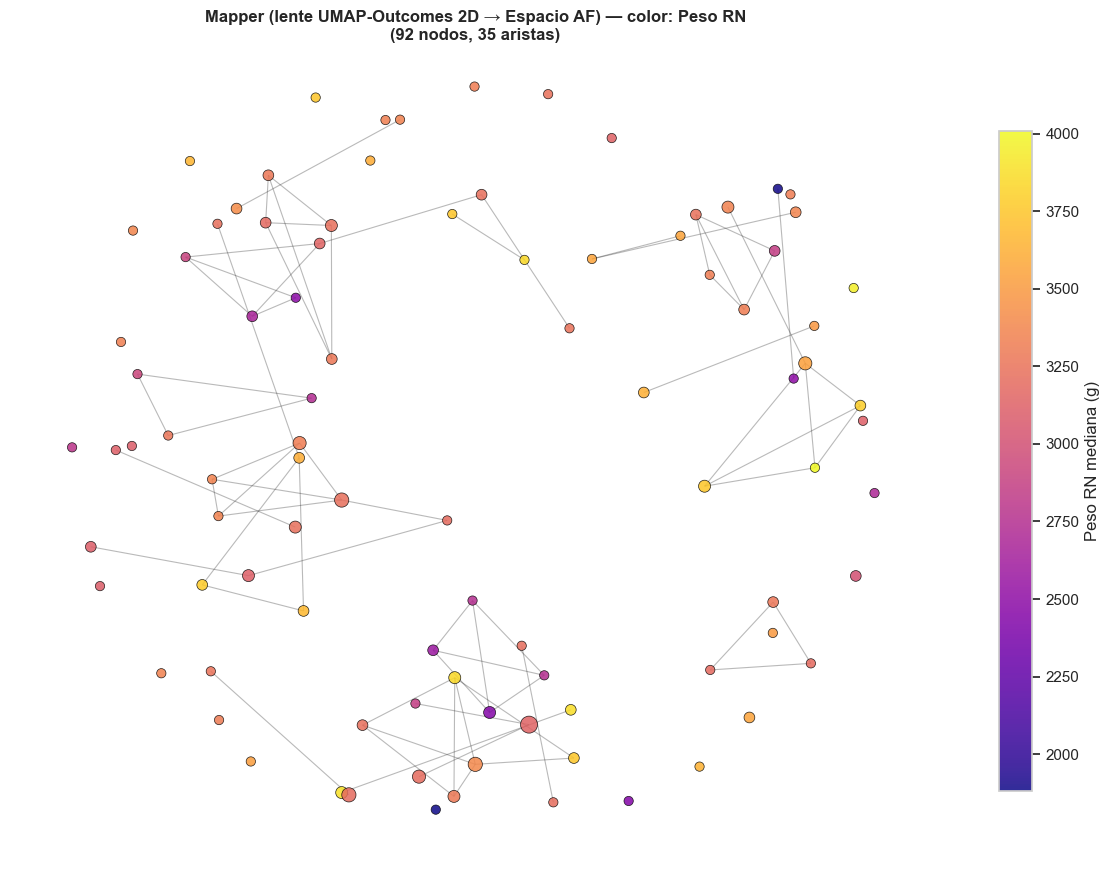

In [31]:
# ── Visualización Mapper 2B ──────────────────────────────────────────────
plot_mapper_graph(
    graph_out_2d, df,
    color_var="Total mg/d AF  suple y pan",
    color_label="AF Total mediana (mg/d)",
    title="Mapper (lente UMAP-Outcomes 2D → Espacio AF) — color: AF Total",
    cmap="viridis"
)

plot_mapper_graph(
    graph_out_2d, df,
    color_var="PN hijo (g)",
    color_label="Peso RN mediana (g)",
    title="Mapper (lente UMAP-Outcomes 2D → Espacio AF) — color: Peso RN",
    cmap="plasma"
)

## 8. Comparación de Mappers

Se compara la estructura de los grafos generados por las distintas lentes
mediante solapamiento de nodos (índice de Jaccard).

In [32]:
# ── Comparación estructural ──────────────────────────────────────────────
print("=== Resumen de Mappers ===\n")

mappers_info = [
    ("Mapper 1A (AF 1D → Out)", graph_af_1d),
    ("Mapper 1B (UMAP-AF → Out)", graph_af_2d),
    ("Mapper 2A (PN 1D → AF)", graph_out_1d),
    ("Mapper 2B (UMAP-Out → AF)", graph_out_2d),
]

for nombre, g in mappers_info:
    n = len(g["nodes"])
    e = sum(len(v) for v in g["links"].values()) // 2
    tamaños = [len(v) for v in g["nodes"].values()]
    print(f"{nombre}:")
    print(f"  Nodos: {n}, Aristas: {e}")
    if tamaños:
        print(f"  Tamaño nodo: med={np.median(tamaños):.0f}, "
              f"min={min(tamaños)}, max={max(tamaños)}")
    print()

=== Resumen de Mappers ===

Mapper 1A (AF 1D → Out):
  Nodos: 22, Aristas: 7
  Tamaño nodo: med=5, min=3, max=248

Mapper 1B (UMAP-AF → Out):
  Nodos: 83, Aristas: 49
  Tamaño nodo: med=5, min=3, max=58

Mapper 2A (PN 1D → AF):
  Nodos: 83, Aristas: 26
  Tamaño nodo: med=5, min=3, max=59

Mapper 2B (UMAP-Out → AF):
  Nodos: 92, Aristas: 35
  Tamaño nodo: med=3, min=3, max=10



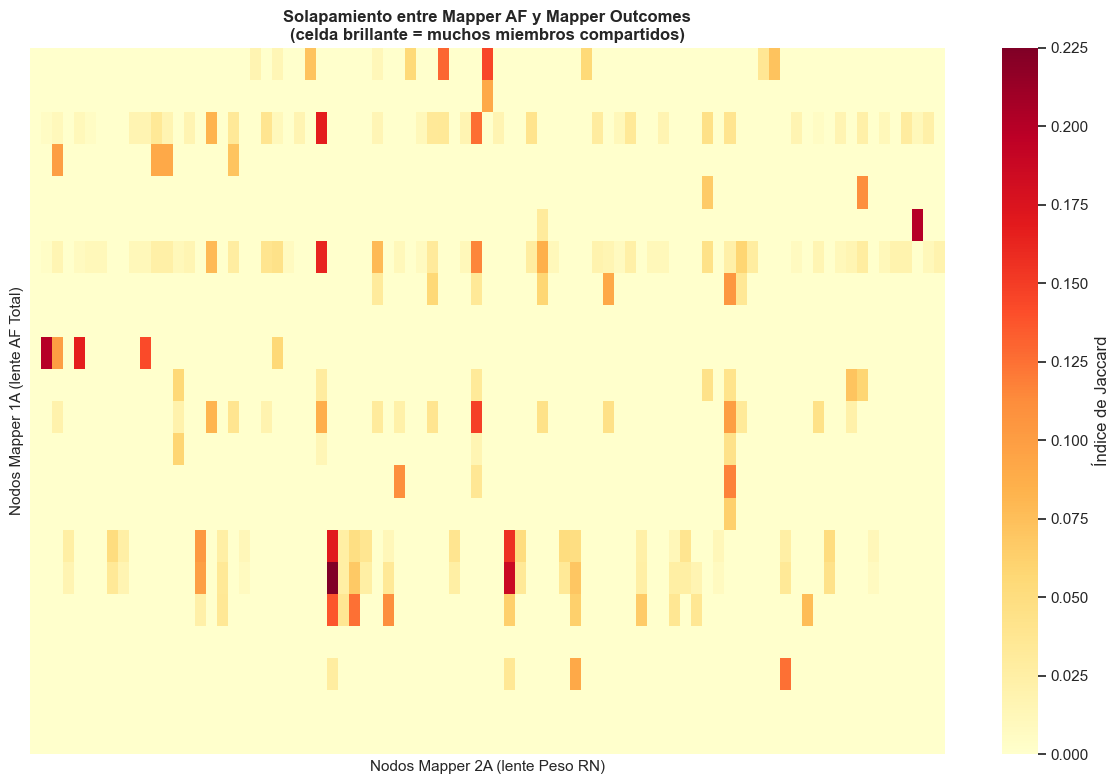

In [33]:
# ── Solapamiento Jaccard entre Mapper 1A y Mapper 2A ─────────────────────
# (los dos mappers con lente 1D — más directamente comparables)

def jaccard_overlap(graph_a, graph_b):
    """Calcula matriz de Jaccard entre nodos de dos mappers."""
    nodes_a = list(graph_a["nodes"].keys())
    nodes_b = list(graph_b["nodes"].keys())
    mat = np.zeros((len(nodes_a), len(nodes_b)))

    for i, na in enumerate(nodes_a):
        set_a = set(graph_a["nodes"][na])
        for j, nb in enumerate(nodes_b):
            set_b = set(graph_b["nodes"][nb])
            union = len(set_a | set_b)
            if union > 0:
                mat[i, j] = len(set_a & set_b) / union
    return mat, nodes_a, nodes_b


if len(graph_af_1d["nodes"]) > 0 and len(graph_out_1d["nodes"]) > 0:
    jac_mat, _, _ = jaccard_overlap(graph_af_1d, graph_out_1d)

    fig, ax = plt.subplots(figsize=(12, 8))
    sns.heatmap(jac_mat, ax=ax, cmap="YlOrRd",
                cbar_kws={"label": "Índice de Jaccard"},
                xticklabels=False, yticklabels=False)
    ax.set_xlabel("Nodos Mapper 2A (lente Peso RN)", fontsize=11)
    ax.set_ylabel("Nodos Mapper 1A (lente AF Total)", fontsize=11)
    ax.set_title("Solapamiento entre Mapper AF y Mapper Outcomes\n"
                 "(celda brillante = muchos miembros compartidos)",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("⚠️  Algún Mapper está vacío, no se puede calcular solapamiento.")

In [34]:
# ── Nodos de interés cruzado ─────────────────────────────────────────────
# Buscar nodos del Mapper 1A (AF→Out) con patrones extremos

if len(graph_af_1d["nodes"]) > 0:
    print("=== Nodos de INTERÉS — Mapper 1A (AF 1D → Outcomes) ===\n")

    # Alta AF + mal outcome
    for node_id, member_ids in graph_af_1d["nodes"].items():
        sub = df.iloc[member_ids]
        af_med = sub["Total mg/d AF  suple y pan"].median()
        pn_med = sub["PN hijo (g)"].median()
        pct_pat = sub["hijo_con_patologia"].mean()

        if af_med > df["Total mg/d AF  suple y pan"].quantile(0.75) and pn_med < df["PN hijo (g)"].quantile(0.25):
            print(f"🔴 Alta AF + Bajo peso: Nodo {node_id} (n={len(member_ids)})")
            print(f"   AF={af_med:.2f} mg/d, Peso RN={pn_med:.0f} g, "
                  f"Patología={pct_pat:.0%}")
            # Variables de confusión
            print(f"   Edad={sub['Edad madre'].median():.0f}, "
                  f"IMC pre={sub['IMC antes'].median():.1f}, "
                  f"Educación={sub['Educación'].median():.0f}")
            print()

        if af_med < df["Total mg/d AF  suple y pan"].quantile(0.25) and pct_pat > 0.15:
            print(f"🟡 Baja AF + Alta patología: Nodo {node_id} (n={len(member_ids)})")
            print(f"   AF={af_med:.2f} mg/d, Peso RN={pn_med:.0f} g, "
                  f"Patología={pct_pat:.0%}")
            print(f"   Edad={sub['Edad madre'].median():.0f}, "
                  f"IMC pre={sub['IMC antes'].median():.1f}, "
                  f"Educación={sub['Educación'].median():.0f}")
            print()

=== Nodos de INTERÉS — Mapper 1A (AF 1D → Outcomes) ===

🔴 Alta AF + Bajo peso: Nodo cube11_cluster1 (n=3)
   AF=5.83 mg/d, Peso RN=2740 g, Patología=0%
   Edad=35, IMC pre=23.2, Educación=7



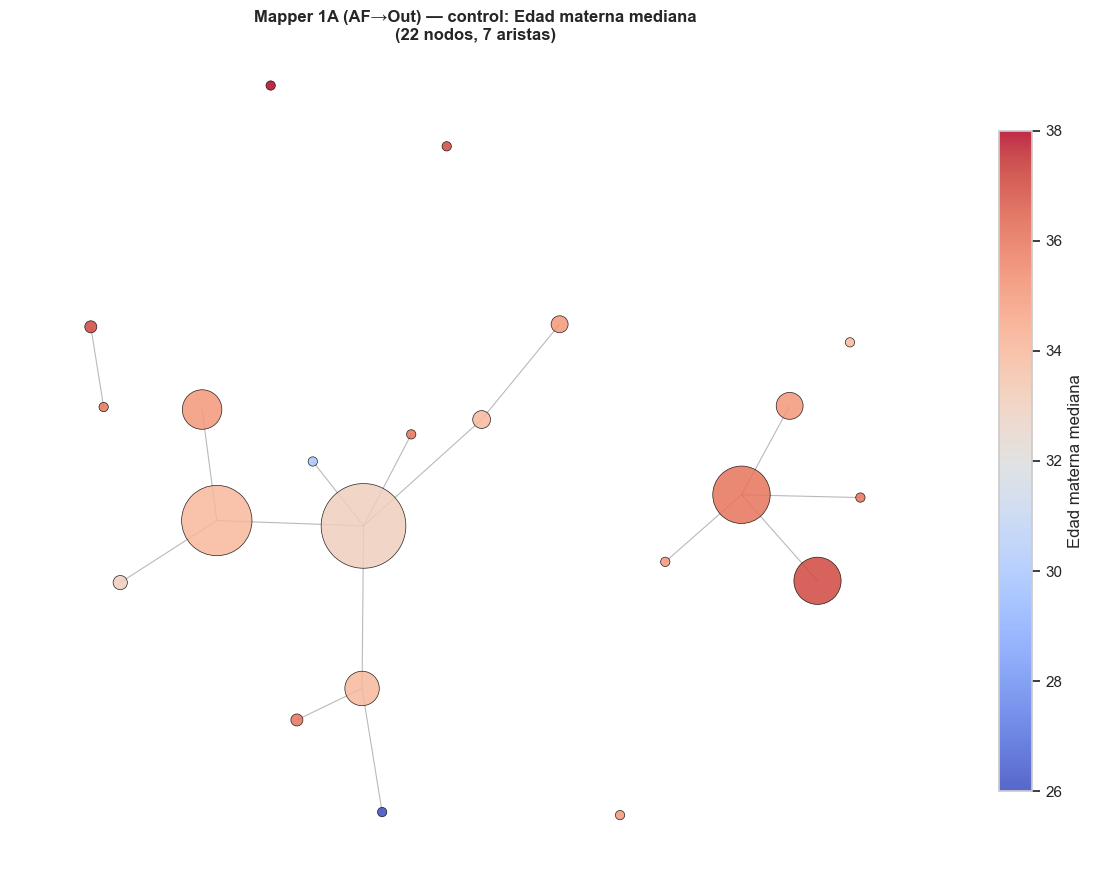

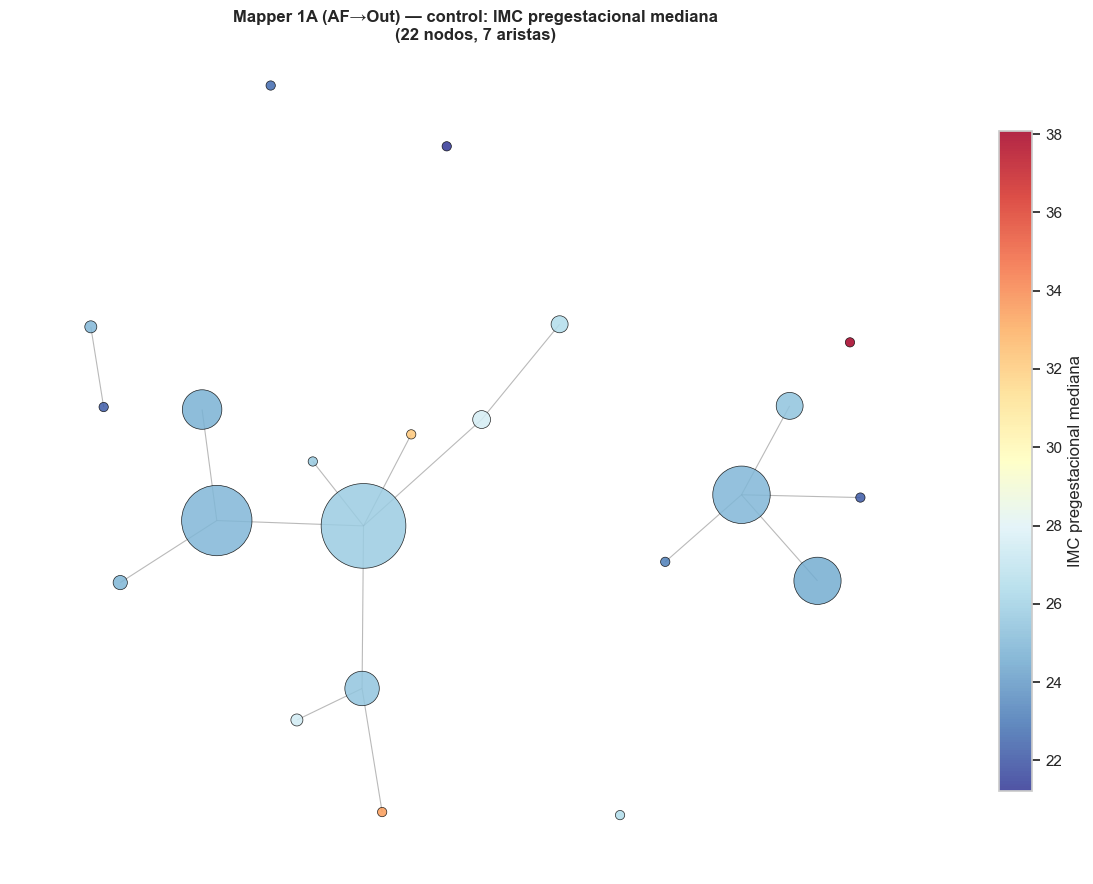

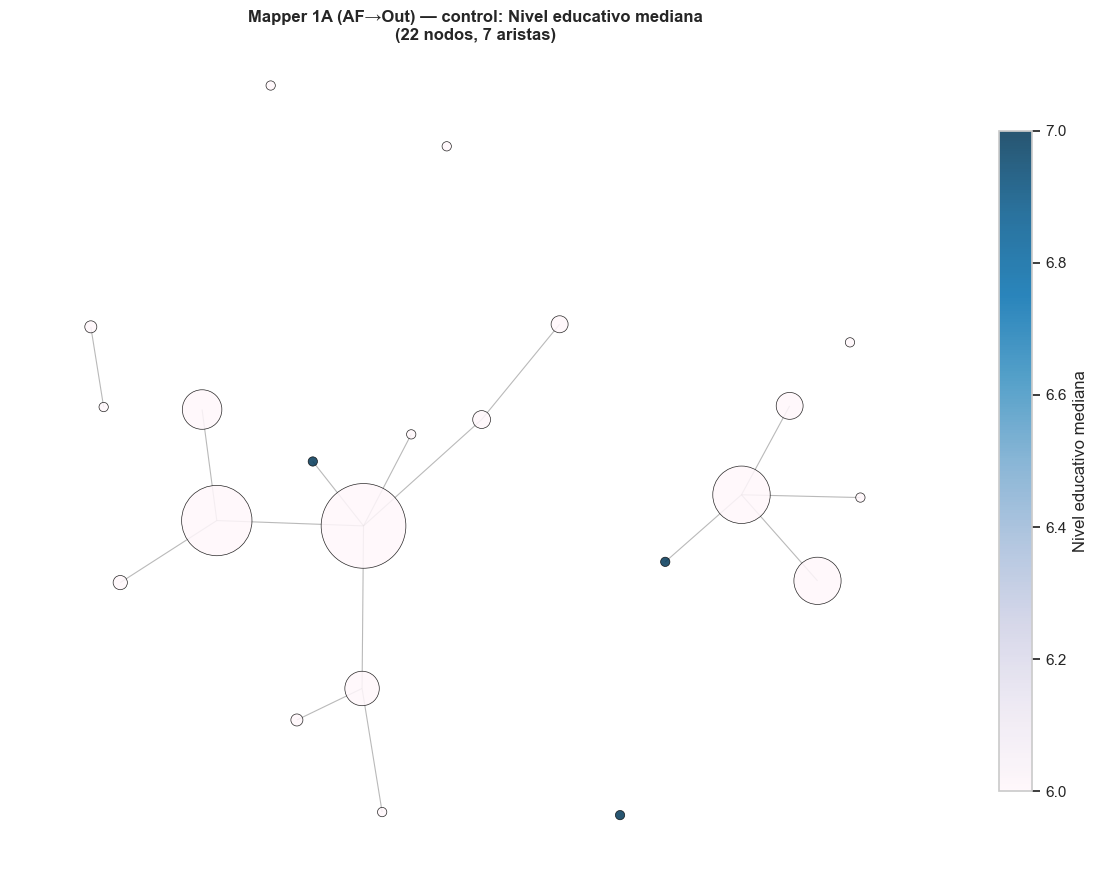

In [35]:
# ── Colorear Mapper 1A por variables de confusión ────────────────────────
for var, label, cmap_name in [
    ("Edad madre", "Edad materna mediana", "coolwarm"),
    ("IMC antes", "IMC pregestacional mediana", "RdYlBu_r"),
    ("Educación", "Nivel educativo mediana", "PuBu"),
]:
    if len(graph_af_1d["nodes"]) > 0:
        plot_mapper_graph(
            graph_af_1d, df,
            color_var=var, color_label=label,
            title=f"Mapper 1A (AF→Out) — control: {label}",
            cmap=cmap_name
        )

## 9. Análisis con variables binarias de AF

Se crea un **perfil de consumo** combinando las binarias de AF y se usa
para colorear los Mappers y hacer análisis de composición por nodo.

In [36]:
# ── Crear perfil de consumo ──────────────────────────────────────────────
def perfil_consumo(row):
    """Clasifica a cada mujer según su patrón de suplementación."""
    consume_saf = row["¿Consume SAF?"]
    consume_maf = row["¿Consumió MAF?"]
    consume_osaf = row["Consumo OSAF completo"]

    if consume_saf == 0 and consume_maf == 0 and consume_osaf == 0:
        return "Sin AF"
    elif consume_saf == 1 and consume_maf == 0 and consume_osaf == 0:
        return "Solo SAF"
    elif consume_saf == 0 and consume_maf == 1 and consume_osaf == 0:
        return "Solo MAF"
    elif consume_saf == 1 and consume_maf == 1:
        return "SAF + MAF"
    else:
        return "Otro/combinado"

df["perfil_af"] = df.apply(perfil_consumo, axis=1)
print("Distribución de perfiles de consumo AF:")
print(df["perfil_af"].value_counts())

Distribución de perfiles de consumo AF:
perfil_af
Solo SAF          531
Solo MAF           83
Sin AF             54
Otro/combinado     37
Name: count, dtype: int64


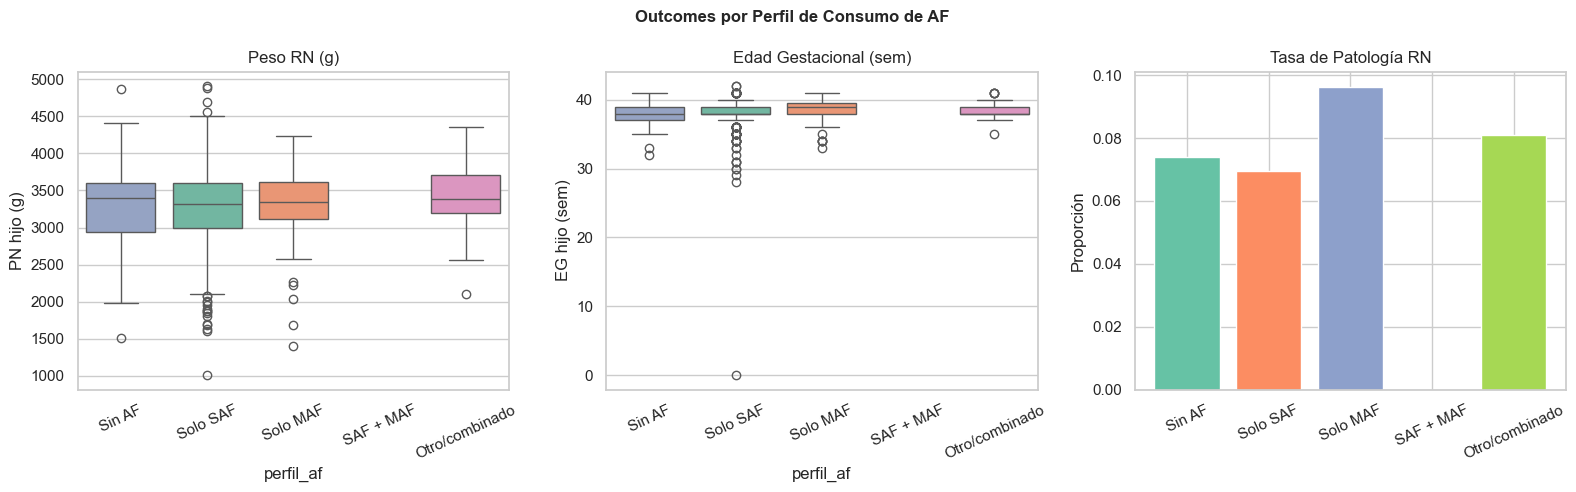

In [37]:
# ── Outcomes por perfil de consumo ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Outcomes por Perfil de Consumo de AF", fontsize=12, fontweight="bold")

orden = ["Sin AF", "Solo SAF", "Solo MAF", "SAF + MAF", "Otro/combinado"]

sns.boxplot(data=df, x="perfil_af", y="PN hijo (g)", ax=axes[0],
            order=orden, palette="Set2", hue="perfil_af", legend=False)
axes[0].set_title("Peso RN (g)")
axes[0].tick_params(axis="x", rotation=25)

sns.boxplot(data=df, x="perfil_af", y="EG hijo (sem)", ax=axes[1],
            order=orden, palette="Set2", hue="perfil_af", legend=False)
axes[1].set_title("Edad Gestacional (sem)")
axes[1].tick_params(axis="x", rotation=25)

# Tasa de patología por perfil
tasa_pat = df.groupby("perfil_af")["hijo_con_patologia"].mean().reindex(orden).fillna(0)
axes[2].bar(range(len(tasa_pat)), tasa_pat.values, color=sns.color_palette("Set2", len(orden)))
axes[2].set_xticks(range(len(tasa_pat)))
axes[2].set_xticklabels(orden, rotation=25)
axes[2].set_title("Tasa de Patología RN")
axes[2].set_ylabel("Proporción")

plt.tight_layout()
plt.show()

=== Composición de perfiles por nodo — Mapper 1A ===
           Nodo   N  Sin AF  Solo SAF  Solo MAF  SAF + MAF  Otro/combinado
 cube0_cluster0  54    0.56      0.13      0.31          0            0.00
 cube0_cluster1   3    0.33      0.33      0.33          0            0.00
 cube1_cluster0 171    0.04      0.63      0.34          0            0.00
 cube1_cluster1   3    0.00      1.00      0.00          0            0.00
 cube1_cluster2   3    0.00      0.67      0.33          0            0.00
 cube1_cluster3   3    0.00      0.33      0.67          0            0.00
 cube2_cluster0 248    0.00      0.86      0.12          0            0.02
 cube2_cluster1   7    0.00      0.86      0.14          0            0.00
 cube2_cluster2   3    0.00      0.33      0.67          0            0.00
 cube2_cluster3   3    0.00      1.00      0.00          0            0.00
 cube3_cluster0  11    0.00      0.82      0.00          0            0.18
 cube3_cluster1  41    0.00      0.93      0.00

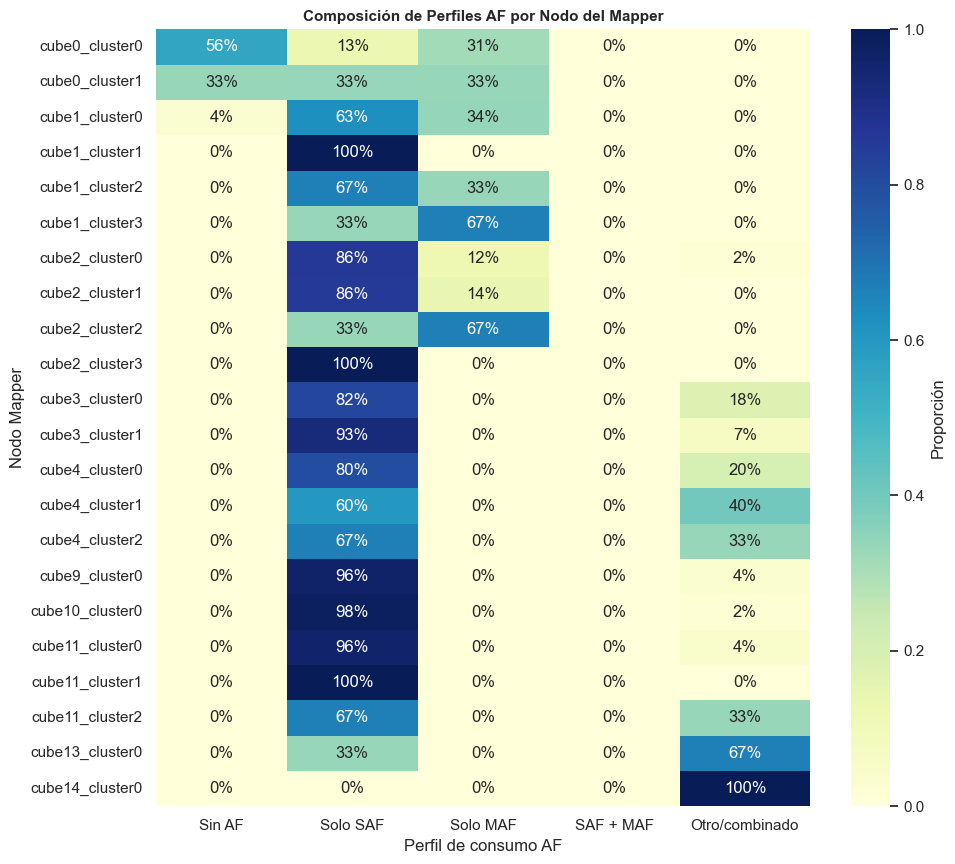

In [38]:
# ── Composición de perfiles por nodo del Mapper 1A ───────────────────────
if len(graph_af_1d["nodes"]) > 0:
    perfil_por_nodo = []
    for node_id, member_ids in graph_af_1d["nodes"].items():
        sub = df.iloc[member_ids]
        counts = sub["perfil_af"].value_counts(normalize=True)
        row = {"Nodo": node_id, "N": len(member_ids)}
        for perfil in orden:
            row[perfil] = counts.get(perfil, 0)
        perfil_por_nodo.append(row)

    df_perfil_nodo = pd.DataFrame(perfil_por_nodo)

    print("=== Composición de perfiles por nodo — Mapper 1A ===")
    print(df_perfil_nodo.round(2).to_string(index=False))

    # Heatmap de composición
    fig, ax = plt.subplots(figsize=(10, max(4, len(df_perfil_nodo) * 0.4)))
    data_hm = df_perfil_nodo[orden].values
    sns.heatmap(data_hm, ax=ax, cmap="YlGnBu", annot=True, fmt=".0%",
                xticklabels=orden, yticklabels=df_perfil_nodo["Nodo"],
                cbar_kws={"label": "Proporción"})
    ax.set_title("Composición de Perfiles AF por Nodo del Mapper",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("Perfil de consumo AF")
    ax.set_ylabel("Nodo Mapper")
    plt.tight_layout()
    plt.show()

## 10. Homología Persistente

Se calcula la homología persistente con complejo de Rips para detectar
características topológicas:
- **H₀:** Componentes conectadas — cuántos "grupos" hay en los datos.
- **H₁:** Ciclos — relaciones circulares/no-lineales entre variables.

In [39]:
# ── Funciones para diagramas de persistencia ─────────────────────────────

def plot_persistence_diagram(diagrams, ax, title, colors=None):
    """Diagrama de persistencia (birth vs death)."""
    if colors is None:
        colors = ["steelblue", "crimson", "green"]
    max_val = 0
    for dim, dgm in enumerate(diagrams):
        finite = dgm[np.isfinite(dgm[:, 1])]
        if len(finite) > 0:
            max_val = max(max_val, finite.max())
    if max_val == 0:
        max_val = 1

    ax.plot([0, max_val * 1.1], [0, max_val * 1.1], "k--", alpha=0.3, lw=1)

    for dim, dgm in enumerate(diagrams):
        finite = dgm[np.isfinite(dgm[:, 1])]
        if len(finite) > 0:
            ax.scatter(finite[:, 0], finite[:, 1], c=colors[dim],
                       s=20, alpha=0.7, label=f"H{dim} ({len(finite)} features)")
        # Puntos infinitos (componente conectada principal)
        inf_pts = dgm[np.isinf(dgm[:, 1])]
        if len(inf_pts) > 0:
            ax.scatter(inf_pts[:, 0], [max_val * 1.05] * len(inf_pts),
                       c=colors[dim], marker="^", s=40, alpha=0.7)

    ax.set_xlabel("Birth")
    ax.set_ylabel("Death")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.legend(fontsize=8)


def plot_barcode(diagrams, ax, title, colors=None):
    """Barcode de persistencia."""
    if colors is None:
        colors = ["steelblue", "crimson", "green"]
    y = 0
    for dim, dgm in enumerate(diagrams):
        finite = dgm[np.isfinite(dgm[:, 1])]
        # Ordenar por persistencia (death - birth) descendente
        if len(finite) > 0:
            pers = finite[:, 1] - finite[:, 0]
            order = np.argsort(-pers)
            for idx in order:
                ax.plot([finite[idx, 0], finite[idx, 1]], [y, y],
                        color=colors[dim], lw=1.5, alpha=0.7)
                y += 1
    ax.set_xlabel("Escala")
    ax.set_ylabel("Feature")
    ax.set_title(title, fontsize=11, fontweight="bold")

Calculando homología persistente sobre espacio AF...
  H₀: 407 features
  H₁: 104 features


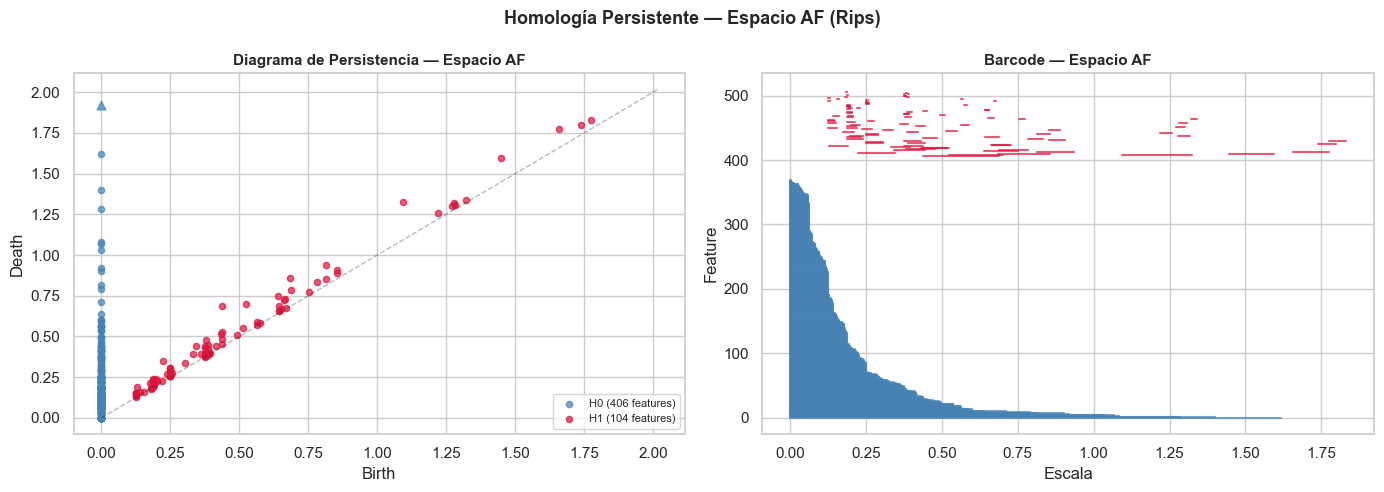

In [40]:
# ── Homología persistente: espacio AF ────────────────────────────────────
print("Calculando homología persistente sobre espacio AF...")
result_af = ripser(X_af, maxdim=1, metric="euclidean")
diagrams_af = result_af["dgms"]

print(f"  H₀: {len(diagrams_af[0])} features")
print(f"  H₁: {len(diagrams_af[1])} features")

fig = plt.figure(figsize=(14, 5))
ax1 = fig.add_subplot(1, 2, 1)
plot_persistence_diagram(diagrams_af, ax1, "Diagrama de Persistencia — Espacio AF")

ax2 = fig.add_subplot(1, 2, 2)
plot_barcode(diagrams_af, ax2, "Barcode — Espacio AF")

fig.suptitle("Homología Persistente — Espacio AF (Rips)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Calculando homología persistente sobre espacio outcomes...
  H₀: 705 features
  H₁: 482 features


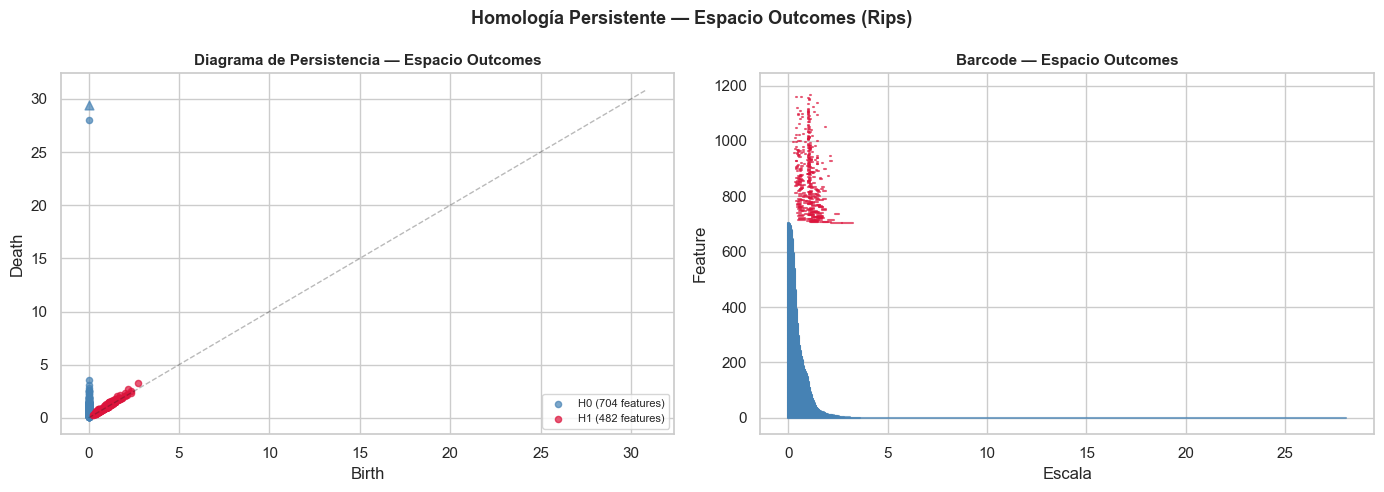

In [41]:
# ── Homología persistente: espacio outcomes ──────────────────────────────
print("Calculando homología persistente sobre espacio outcomes...")
result_out = ripser(X_out, maxdim=1, metric="euclidean")
diagrams_out = result_out["dgms"]

print(f"  H₀: {len(diagrams_out[0])} features")
print(f"  H₁: {len(diagrams_out[1])} features")

fig = plt.figure(figsize=(14, 5))
ax1 = fig.add_subplot(1, 2, 1)
plot_persistence_diagram(diagrams_out, ax1, "Diagrama de Persistencia — Espacio Outcomes")

ax2 = fig.add_subplot(1, 2, 2)
plot_barcode(diagrams_out, ax2, "Barcode — Espacio Outcomes")

fig.suptitle("Homología Persistente — Espacio Outcomes (Rips)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Calculando homología persistente sobre espacio combinado (AF + Outcomes)...
  H₀: 705 features
  H₁: 506 features


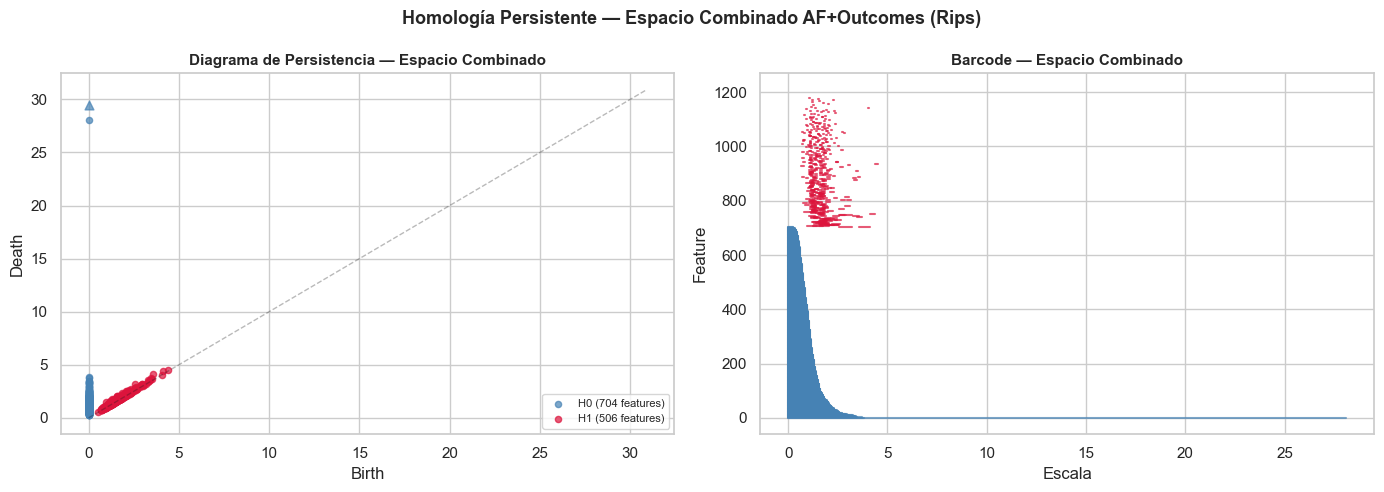

In [42]:
# ── Homología persistente: espacio combinado ─────────────────────────────
print("Calculando homología persistente sobre espacio combinado (AF + Outcomes)...")
result_comb = ripser(X_comb, maxdim=1, metric="euclidean")
diagrams_comb = result_comb["dgms"]

print(f"  H₀: {len(diagrams_comb[0])} features")
print(f"  H₁: {len(diagrams_comb[1])} features")

fig = plt.figure(figsize=(14, 5))
ax1 = fig.add_subplot(1, 2, 1)
plot_persistence_diagram(diagrams_comb, ax1, "Diagrama de Persistencia — Espacio Combinado")

ax2 = fig.add_subplot(1, 2, 2)
plot_barcode(diagrams_comb, ax2, "Barcode — Espacio Combinado")

fig.suptitle("Homología Persistente — Espacio Combinado AF+Outcomes (Rips)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

C:\Users\Vivi\AppData\Local\Temp\ipykernel_6416\2818060860.py:25: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Vivi\Documents\VS\escuela\tda_project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


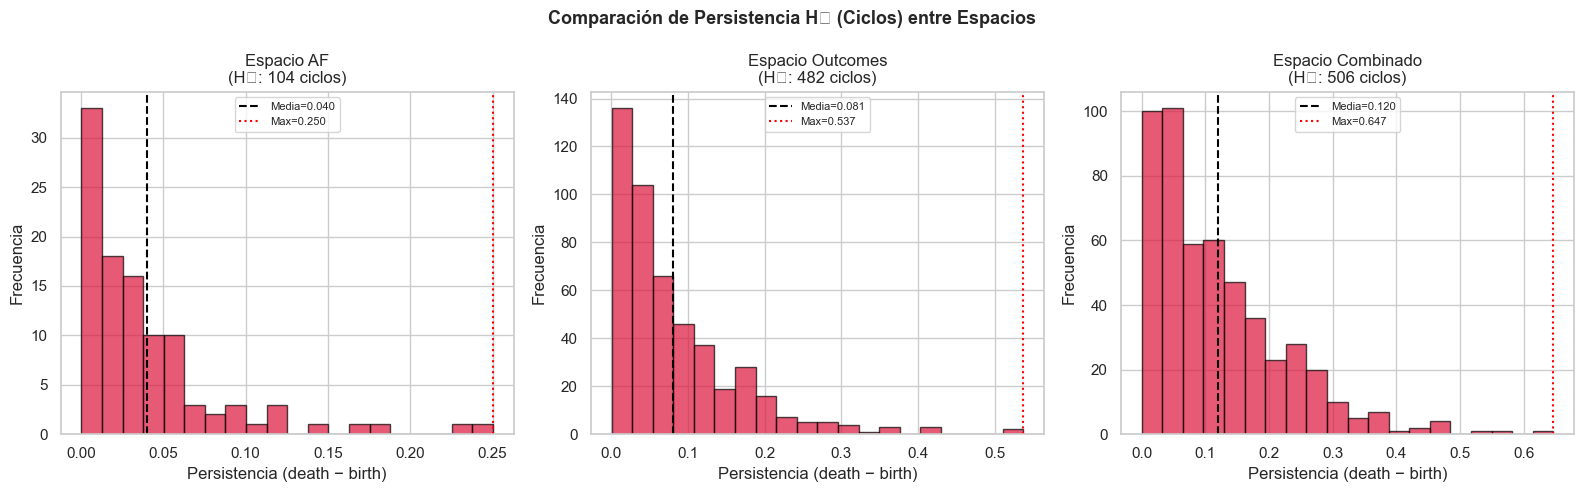

In [43]:
# ── Comparación de persistencia entre espacios ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Comparación de Persistencia H₁ (Ciclos) entre Espacios",
             fontsize=13, fontweight="bold")

for ax, dgms, titulo in zip(
    axes,
    [diagrams_af, diagrams_out, diagrams_comb],
    ["AF", "Outcomes", "Combinado"]
):
    h1 = dgms[1]
    finite = h1[np.isfinite(h1[:, 1])]
    if len(finite) > 0:
        pers = finite[:, 1] - finite[:, 0]
        ax.hist(pers, bins=20, color="crimson", alpha=0.7, edgecolor="black")
        ax.axvline(np.mean(pers), color="black", ls="--",
                   label=f"Media={np.mean(pers):.3f}")
        ax.axvline(np.max(pers), color="red", ls=":",
                   label=f"Max={np.max(pers):.3f}")
    ax.set_title(f"Espacio {titulo}\n(H₁: {len(finite)} ciclos)")
    ax.set_xlabel("Persistencia (death − birth)")
    ax.set_ylabel("Frecuencia")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 11. Resumen de hallazgos

### Guía de interpretación:
**Mapper:**
- Nodos grandes = muchas mujeres con patrones similares
- Aristas = solapamiento (mujeres que comparten nodos)
- Gradiente de color = variación de la variable coloreada
- Si el gradiente de AF se alinea con el gradiente de outcomes → relación
- Ramas o brazos separados = subpoblaciones distintas

**Homología Persistente:**

- H₀ barras largas = grupos bien separados
- H₁ barras largas = ciclos persistentes (relaciones no-lineales)
- Comparar persistencia entre espacios AF y outcomes:
  - Si AF tiene más ciclos H₁ → estructura más compleja en patrones de consumo
  - Si combinado tiene ciclos que no aparecen en AF ni outcomes solos
    → la relación AF↔outcomes crea estructura topológica nueva